In [500]:
import warnings
warnings.filterwarnings("ignore")

import os
import sys
import time
import json
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import pyomo.environ as pe
from copy import deepcopy

import good
from good.reload import deep_reload


## Configuration

Set up the parameters for the analysis:


In [501]:
# Configuration
GRAPH_FILE = 'Examples/California.json'  # Path to graph JSON file
POLICIES_FILE = 'Examples/policies.json'  # Path to policies JSON file (optional)

# Time period: 7 days * 24 hours = 168 hours
# Adjust steps based on your data. This assumes starting from hour 0
START_HOUR = 0  # Starting hour (0-indexed)
NUM_HOURS = 7 * 24  # 168 hours for 7 days
STEPS = (START_HOUR, START_HOUR + NUM_HOURS)

# EV Charging Load
# This should be a 168-hour array (7 days) of hourly charging load in Watts
# For example, if you have a CSV file:
# ev_charging_load = pd.read_csv('ev_charging_load.csv')['load'].values
# Or create a sample load pattern:
EV_CHARGING_LOAD_FILE = None  # Set to path if loading from file

# If no file, create a sample pattern (replace with your actual data)
if EV_CHARGING_LOAD_FILE is None:
    # Sample: higher charging during evening hours (6 PM - 10 PM)
    np.random.seed(42)
    max_peak_load = 1e9  # Maximum peak load: 1 GW
    max_total_energy = 7 * 24 * 1e9 * 3600  # Maximum total energy: 168 GWh (in W-s)
    
    hourly_pattern = np.sin(np.arange(7 * 24) * 2 * np.pi / 24) * 0.3 + 1.0
    daily_variation = np.random.normal(1.0, 0.1, 7 * 24)
    ev_charging_load = hourly_pattern * daily_variation
    ev_charging_load = np.maximum(ev_charging_load, 0)  # Ensure non-negative
    
    # Apply constraints: peak ≤ 1 GW AND total energy ≤ 168 GWh
    # First, normalize to peak = 1 GW
    if ev_charging_load.max() > 0:
        ev_charging_load = ev_charging_load / ev_charging_load.max() * max_peak_load
    
    # Check total energy constraint: total ≤ 168 GWh
    # Total energy = sum(load) * 3600 seconds (assuming hourly time steps)
    total_energy = ev_charging_load.sum() * 3600  # W-s
    if total_energy > max_total_energy:
        # Scale down proportionally to meet total energy constraint
        # This will reduce peak proportionally
        scale_factor = max_total_energy / total_energy
        ev_charging_load = ev_charging_load * scale_factor
        print(f"  Note: Scaled down to meet total energy constraint of 168 GWh")
        print(f"        Peak reduced from 1.00 GW to {ev_charging_load.max()/1e9:.3f} GW")
    else:
        # Total energy is OK, but check if we can scale up to reach peak = 1 GW
        # while still meeting total energy constraint
        # This would only happen if the pattern has low load factor
        current_peak = ev_charging_load.max()
        if current_peak < max_peak_load:
            # Check if scaling to peak = 1 GW would exceed total energy
            scale_to_peak = max_peak_load / current_peak
            scaled_total = total_energy * scale_to_peak
            if scaled_total <= max_total_energy:
                ev_charging_load = ev_charging_load * scale_to_peak
else:
    # Load from file (adjust column name as needed)
    ev_data = pd.read_csv(EV_CHARGING_LOAD_FILE)
    ev_charging_load = ev_data['load'].values  # Adjust column name as needed
    assert len(ev_charging_load) == 7 * 24, f"EV load must be 7*24={7*24} hours, got {len(ev_charging_load)}"
    
    max_peak_load = 1e9  # 1 GW
    max_total_energy = 7 * 24 * 1e9 * 3600  # 168 GWh (in W-s)
    
    # Apply both constraints
    # First, ensure peak doesn't exceed 1 GW
    if ev_charging_load.max() > max_peak_load:
        ev_charging_load = ev_charging_load / ev_charging_load.max() * max_peak_load
    
    # Then, ensure total energy doesn't exceed 168 GWh
    total_energy = ev_charging_load.sum() * 3600  # W-s
    if total_energy > max_total_energy:
        scale_factor = max_total_energy / total_energy
        ev_charging_load = ev_charging_load * scale_factor
        print(f"  Note: Scaled down to meet total energy constraint of 168 GWh")
        print(f"        Peak reduced to {ev_charging_load.max()/1e9:.3f} GW")

print(f"EV Charging Load Summary:")
print(f"  Time period: {NUM_HOURS} hours ({NUM_HOURS/24:.0f} days)")
print(f"  Total energy: {ev_charging_load.sum() / 1e9:.2f} GWh")
print(f"  Average hourly load: {ev_charging_load.mean() / 1e9:.2f} GW")
print(f"  Peak hourly load: {ev_charging_load.max() / 1e9:.2f} GW")


EV Charging Load Summary:
  Time period: 168 hours (7 days)
  Total energy: 106.42 GWh
  Average hourly load: 0.63 GW
  Peak hourly load: 1.00 GW


## Load Graph and Prepare Scenarios


In [502]:
# Load the graph
deep_reload(good)
graph = good.graph.graph_from_json(GRAPH_FILE)

# DISABLE CAPACITY EXPANSION: Set all capex_capacity to 0
print("\nDisabling capacity expansion...")
capex_count = 0
for node_name, node_data in graph._node.items():
    if 'assets' in node_data:
        for asset_name, asset_data in node_data['assets'].items():
            if 'capex_capacity' in asset_data and asset_data['capex_capacity'] > 0:
                asset_data['capex_capacity'] = 0
                asset_data['capex_cost'] = 0
                capex_count += 1
print(f"  Disabled capacity expansion for {capex_count} assets")

# Load policies if provided
if os.path.exists(POLICIES_FILE):
    policies = good.utilities.read_json(POLICIES_FILE)
else:
    policies = {}
    print("No policies file found, running without policies")

print(f"Graph loaded with {len(graph.nodes)} nodes")
print(f"Regions: {list(graph.nodes.keys())}")



Disabling capacity expansion...
  Disabled capacity expansion for 172 assets
Graph loaded with 6 nodes
Regions: ['WEC_BANC', 'WEC_CALN', 'WEC_LADW', 'WEC_SDGE', 'WECC_IID', 'WECC_SCE']


In [503]:
# Network Configuration
# CRITICAL: Define steps to limit optimization to 7 days (168 hours)
# This ensures the Network only optimizes for the specified time period

kw = {
    'verbose': True,
    'steps': STEPS,  # (START_HOUR, START_HOUR + NUM_HOURS) = (0, 168) for 7 days
    'amortization_period': 31536000,  # 1 year in seconds (for cost calculations)
    'time_step': 3600,  # 1 hour in seconds
    'shortfall_capacity': np.inf,  # Allow unlimited shortfall
    'shortfall_cost': 1e3,  # High cost for shortfall (penalty)
    'wastage_capacity': np.inf,  # Allow unlimited wastage
    'wastage_cost': 1e3,  # High cost for wastage (penalty)
}

# Solver Configuration with better options for harder problems
solver_kw = {
    'solver': {
        '_name': 'cbc',
        # Add solver options for better performance
        'options': {
            'seconds': 300,  # Timeout after 5 minutes
            'threads': 4,  # Use multiple threads if available
            'maxSolutions': 1,  # Stop after first solution
        }
    },
    'tee': True,  # Print solver output to see progress
}

print("=" * 60)
print("NETWORK CONFIGURATION")
print("=" * 60)
print(f"Time steps: {kw['steps']} (hours {kw['steps'][0]} to {kw['steps'][1]})")
print(f"Number of hours: {kw['steps'][1] - kw['steps'][0]} hours ({NUM_HOURS/24:.1f} days)")
print(f"Amortization period: {kw['amortization_period'] / 31536000:.1f} years")
print(f"Solver: {solver_kw['solver']['_name']}")
print(f"Solver timeout: {solver_kw['solver']['options']['seconds']} seconds")
print("=" * 60)

NETWORK CONFIGURATION
Time steps: (0, 168) (hours 0 to 168)
Number of hours: 168 hours (7.0 days)
Amortization period: 1.0 years
Solver: cbc
Solver timeout: 300 seconds


## Function to Add EV Charging Load to Graph


In [504]:
def slice_graph_profiles(graph, start_hour=0, num_hours=168):
    """
    Slice all profiles in the graph to match the specified time period.
    This ensures all assets use the same time period for fair comparison.
    
    Parameters:
    -----------
    graph : networkx.DiGraph
        The graph to modify
    start_hour : int, optional
        Starting hour index for slicing profiles (default: 0)
    num_hours : int, optional
        Number of hours to use from profiles (default: 168 for 7 days)
    
    Returns:
    -------
    graph : networkx.DiGraph
        Modified graph with all profiles sliced to the time period
    """
    graph = deepcopy(graph)
    
    for node_name, node_data in graph._node.items():
        # Get profiles dictionary if it exists
        profiles_dict = node_data.get('profiles', {})
        
        # Slice profiles in the profiles dictionary
        for profile_name, profile_data in profiles_dict.items():
            if isinstance(profile_data, (list, np.ndarray)):
                profile_array = np.array(profile_data) if isinstance(profile_data, list) else profile_data
                
                # Slice profile to match the time period
                if len(profile_array) > num_hours:
                    profiles_dict[profile_name] = profile_array[start_hour:start_hour + num_hours].tolist()
                elif len(profile_array) < num_hours:
                    # If profile is shorter, tile it to match (for weekly profiles)
                    if num_hours % len(profile_array) == 0:
                        reps = num_hours // len(profile_array)
                        profiles_dict[profile_name] = np.tile(profile_array, reps).tolist()
                    else:
                        # Pad with last value if needed
                        profiles_dict[profile_name] = np.pad(profile_array, (0, num_hours - len(profile_array)), mode='edge').tolist()
        
        # Slice profiles in assets
        if 'assets' in node_data:
            for asset_name, asset_data in node_data['assets'].items():
                profile = asset_data.get('profile', None)
                
                if profile is not None:
                    # Handle string references to profiles
                    if isinstance(profile, str):
                        # The profile in profiles_dict is already sliced above
                        continue
                    elif isinstance(profile, (list, np.ndarray)):
                        profile_array = np.array(profile) if isinstance(profile, list) else profile
                        
                        # Slice profile to match the time period
                        if len(profile_array) > num_hours:
                            asset_data['profile'] = profile_array[start_hour:start_hour + num_hours].tolist()
                        elif len(profile_array) < num_hours:
                            # If profile is shorter, tile it to match (for weekly profiles)
                            if num_hours % len(profile_array) == 0:
                                reps = num_hours // len(profile_array)
                                asset_data['profile'] = np.tile(profile_array, reps).tolist()
                            else:
                                # Pad with last value if needed
                                asset_data['profile'] = np.pad(profile_array, (0, num_hours - len(profile_array)), mode='edge').tolist()
    
    return graph



In [505]:
def add_ev_charging_load(graph, ev_charging_load, region_name=None, start_hour=0, num_hours=168):
    """
    Add EV charging load to the graph.
    
    CRITICAL FIX: This function first calls slice_graph_profiles to ensure that 
    ALL profiles (Solar, Wind, Hydro, etc.) are sliced to the exact same 
    time window as the Load. This prevents "Time Mismatch" errors where 
    Load is from Week X but Solar is from Week 1.
    """
    # 1. SLICE THE ENTIRE GRAPH FIRST
    # This creates a deepcopy and ensures the background (Solar/Wind) 
    # matches the user's requested time period [start_hour : start_hour + num_hours]
    graph = slice_graph_profiles(graph, start_hour, num_hours)
    
    # EV load is in absolute Watts - we need to add it properly
    max_ev_load = ev_charging_load.max()
    total_ev_energy = ev_charging_load.sum() / 1e9  # GWh
    
    print(f"\nAdding EV charging load:")
    print(f"  Peak load: {max_ev_load / 1e9:.2f} GW")
    print(f"  Total energy: {total_ev_energy:.2f} GWh")
    
    if region_name is None:
        # Distribute EV load proportionally to existing base loads
        total_base_load = 0
        base_loads = {}
        
        # Search for base load assets
        for node_name, node_data in graph._node.items():
            if 'assets' in node_data:
                for asset_name, asset_data in node_data['assets'].items():
                    asset_class = asset_data.get('_class', 'unknown')
                    # Look for Load assets, ideally named 'base_load'
                    is_load = asset_class == 'Load'
                    has_base_load = 'base_load' in asset_name.lower()
                    
                    if is_load and has_base_load:
                        base_capacity = asset_data.get('installed_capacity', 0)
                        # Sum absolute values
                        if node_name not in base_loads:
                            base_loads[node_name] = 0
                        base_loads[node_name] += abs(base_capacity)
                        total_base_load += abs(base_capacity)
        
        # Fallback if no specific 'base_load' named assets found
        if total_base_load == 0:
            print("  WARNING: No 'base_load' assets found. Distributing to all 'Load' assets.")
            for node_name, node_data in graph._node.items():
                if 'assets' in node_data:
                    for asset_name, asset_data in node_data['assets'].items():
                        if asset_data.get('_class') == 'Load':
                            cap = asset_data.get('installed_capacity', 0)
                            base_loads[node_name] = base_loads.get(node_name, 0) + abs(cap)
                            total_base_load += abs(cap)
                            
        print(f"  Total base load capacity found: {total_base_load / 1e9:.2f} GW")
        
        if total_base_load == 0:
            raise ValueError("No load assets found in graph to attach EV load to!")
        
        # Add EV load proportionally
        for node_name, node_data in graph._node.items():
            if node_name in base_loads and total_base_load > 0:
                proportion = base_loads[node_name] / total_base_load
                # Calculate the specific EV load curve for this region
                ev_load_profile_for_region = ev_charging_load * proportion
                
                # Attach to the specific asset
                target_found = False
                for asset_name, asset_data in node_data['assets'].items():
                    # Try to match the logic above to find the same asset
                    is_base = 'base_load' in asset_name.lower() if 'base_load' in str(node_data['assets']) else True
                    
                    if asset_data.get('_class') == 'Load' and is_base:
                        # Get existing profile (WHICH IS NOW ALREADY SLICED to 168 hours)
                        existing_profile = asset_data.get('profile', None)
                        
                        # Handle string references to shared profiles
                        if isinstance(existing_profile, str):
                            existing_profile = node_data.get('profiles', {}).get(existing_profile)
                        
                        if existing_profile is not None:
                            # Convert to numpy for addition
                            existing_arr = np.array(existing_profile)
                            
                            # Get existing capacity (in Watts, negative for loads)
                            existing_capacity = asset_data.get('installed_capacity', 0)
                            existing_capacity_abs = abs(existing_capacity)
                            
                            # Ensure lengths match (Diagnostic)
                            if len(existing_arr) != len(ev_load_profile_for_region):
                                # If this happens, slice_graph_profiles failed or EV load is wrong size
                                print(f"  ERROR: Length mismatch at {asset_name}. Profile: {len(existing_arr)}, EV: {len(ev_load_profile_for_region)}")
                                # Force slice to be safe
                                min_len = min(len(existing_arr), len(ev_load_profile_for_region))
                                existing_arr = existing_arr[:min_len]
                                ev_load_profile_for_region = ev_load_profile_for_region[:min_len]

                            # CRITICAL FIX: Convert per-unit profile to absolute, add EV load, convert back
                            # existing_arr is per-unit (0-1), capacity is in Watts
                            # Step 1: Convert to absolute load (Watts)
                            existing_load_abs = existing_arr * existing_capacity_abs
                            
                            # Step 2: Add EV load (already in absolute Watts)
                            new_load_abs = existing_load_abs + ev_load_profile_for_region
                            
                            # Step 3: Calculate new capacity (add peak EV load proportion)
                            ev_capacity_for_region = ev_load_profile_for_region.max()
                            new_capacity_abs = existing_capacity_abs + ev_capacity_for_region
                            
                            # Step 4: Convert back to per-unit profile
                            # Avoid division by zero
                            if new_capacity_abs > 0:
                                new_profile = new_load_abs / new_capacity_abs
                            else:
                                new_profile = existing_arr  # Fallback
                            
                            # Update the asset
                            asset_data['profile'] = new_profile.tolist()
                            # Update capacity (keep original sign - negative for loads)
                            asset_data['installed_capacity'] = -new_capacity_abs if existing_capacity < 0 else new_capacity_abs
                            
                            target_found = True
                            # Only add to one asset per node to avoid double counting if multiple match
                            break 
                
                if not target_found:
                    print(f"  Warning: Could not add EV load to node {node_name}")

    else:
        # Add to specific region (Simplification: logic similar to above but filtered by region)
        pass # (Original code for region specific goes here if needed, omitted for brevity as None is default)

    return graph

In [506]:
# 1. Run Baseline Scenario
print("=" * 60)
print("RUNNING BASELINE SCENARIO (No EV)...")
print("=" * 60)

# VERIFY: Check that kw is correctly set
print(f"\nVERIFICATION: Network configuration")
print(f"  kw['steps'] = {kw['steps']}")
print(f"  Expected: (0, 168) for 7 days")
print(f"  Number of time steps: {kw['steps'][1] - kw['steps'][0]}")
assert kw['steps'] == (0, 168), f"ERROR: kw['steps'] is {kw['steps']}, expected (0, 168)!"

# Create baseline graph - slice profiles to match 7-day period
baseline_graph = slice_graph_profiles(graph, start_hour=START_HOUR, num_hours=NUM_HOURS)

# Build network
baseline_network = good.optimization.network.Network(**kw).from_graph(
    baseline_graph, policies)

# VERIFY: Check Network's steps attribute
print(f"\nVERIFICATION: Network object")
print(f"  baseline_network.steps = {baseline_network.steps}")
assert baseline_network.steps == (0, 168), f"ERROR: Network.steps is {baseline_network.steps}, expected (0, 168)!"

baseline_network.build()

# VERIFY: Check model's time steps after building
print(f"\nVERIFICATION: Model time steps")
print(f"  model.start = {baseline_network.model.start.value}")
print(f"  model.stop = {baseline_network.model.stop.value}")
print(f"  len(model.steps) = {len(baseline_network.model.steps)}")
expected_steps = 168
actual_steps = len(baseline_network.model.steps)
print(f"  Expected: {expected_steps} time steps")
print(f"  Actual: {actual_steps} time steps")
if actual_steps != expected_steps:
    print(f"  ⚠️  WARNING: Model has {actual_steps} time steps, expected {expected_steps}!")
    print(f"     This means the model is NOT limited to 7 days!")
else:
    print(f"  ✓ Model correctly limited to {actual_steps} time steps (7 days)")

# Print model size to verify
size_report = baseline_network.size()
print(f"\nModel Size Report:")
print(f"  Variables: {size_report.overall.variables}")
print(f"  Constraints: {size_report.overall.constraints}")
print(f"  (For 168 hours, expect ~70k-200k variables, not millions)")

# Solve
baseline_network.solve(**solver_kw)
baseline_solution = baseline_network.solution

# Get objective value (only available after solving)
baseline_obj = pe.value(baseline_network.model.objective) if hasattr(baseline_network, 'model') else None
print(f'\nBaseline Objective Value: {baseline_obj}')

# 2. Run EV Scenario
print("\n" + "=" * 60)
print("RUNNING EV SCENARIO (With EV Load)...")
print("=" * 60)

# Create graph with EV charging load
ev_graph = add_ev_charging_load(graph, ev_charging_load, start_hour=START_HOUR, num_hours=NUM_HOURS)

# Build network
ev_network = good.optimization.network.Network(**kw).from_graph(
    ev_graph, policies)

# VERIFY: Check Network's steps attribute
print(f"\nVERIFICATION: EV Network object")
print(f"  ev_network.steps = {ev_network.steps}")
assert ev_network.steps == (0, 168), f"ERROR: Network.steps is {ev_network.steps}, expected (0, 168)!"

ev_network.build()

# VERIFY: Check model's time steps after building
print(f"\nVERIFICATION: EV Model time steps")
print(f"  model.start = {ev_network.model.start.value}")
print(f"  model.stop = {ev_network.model.stop.value}")
print(f"  len(model.steps) = {len(ev_network.model.steps)}")
actual_steps_ev = len(ev_network.model.steps)
if actual_steps_ev != expected_steps:
    print(f"  ⚠️  WARNING: Model has {actual_steps_ev} time steps, expected {expected_steps}!")
else:
    print(f"  ✓ Model correctly limited to {actual_steps_ev} time steps (7 days)")

# Print model size
size_report_ev = ev_network.size()
print(f"\nModel Size Report:")
print(f"  Variables: {size_report_ev.overall.variables}")
print(f"  Constraints: {size_report_ev.overall.constraints}")
# Quick feasibility check: Verify total capacity vs total load
print("\nFEASIBILITY CHECK:")
total_capacity = 0
total_load = 0

for node_name, node_data in ev_graph._node.items():
    profiles_dict = node_data.get('profiles', {})
    for asset_name, asset_data in node_data.get('assets', {}).items():
        if asset_data.get('_class') == 'Producer':
            cap = asset_data.get('installed_capacity', 0)
            profile = asset_data.get('profile', [])
            if isinstance(profile, str):
                profile = profiles_dict.get(profile, [])
            if profile and len(profile) > 0:
                profile_array = np.array(profile, dtype=float)
                if len(profile_array) > NUM_HOURS:
                    profile_slice = profile_array[START_HOUR:START_HOUR + NUM_HOURS]
                else:
                    profile_slice = profile_array[:NUM_HOURS] if len(profile_array) >= NUM_HOURS else profile_array
                max_gen = (profile_slice * cap).max()
                total_capacity += max_gen if max_gen > 0 else 0
        
        elif asset_data.get('_class') == 'Load':
            cap = asset_data.get('installed_capacity', 0)
            profile = asset_data.get('profile', [])
            if isinstance(profile, str):
                profile = profiles_dict.get(profile, [])
            if profile and len(profile) > 0:
                profile_array = np.array(profile, dtype=float)
                if len(profile_array) > NUM_HOURS:
                    profile_slice = profile_array[START_HOUR:START_HOUR + NUM_HOURS]
                else:
                    profile_slice = profile_array[:NUM_HOURS] if len(profile_array) >= NUM_HOURS else profile_array
                max_load = abs((profile_slice * cap).max())
                total_load += max_load

print(f"  Total maximum generation capacity: {total_capacity / 1e9:.2f} GW")
print(f"  Total maximum load (including EV): {total_load / 1e9:.2f} GW")
print(f"  Reserve margin: {(total_capacity - total_load) / 1e9:.2f} GW")
if total_load > total_capacity * 1.1:  # 10% buffer
    print(f"  ⚠️  WARNING: Load may exceed capacity - problem may be infeasible!")
# Solve with timeout and error handling
print("\nSolving EV scenario (this may take longer due to additional load)...")
try:
    ev_network.solve(**solver_kw)
    
    # Check if solution is optimal
    if hasattr(ev_network, 'result'):
        solver_status = ev_network.result.solver.status
        termination_condition = ev_network.result.solver.termination_condition
        
        print(f"\nSolver Status: {solver_status}")
        print(f"Termination Condition: {termination_condition}")
        
        if termination_condition != 'optimal':
            print(f"⚠️  WARNING: Solver did not find optimal solution!")
            print(f"   Status: {solver_status}")
            print(f"   Condition: {termination_condition}")
            if 'infeasible' in str(termination_condition).lower():
                print(f"   The problem may be infeasible - check if EV load is too large")
    
    ev_solution = ev_network.solution
    
    # Get objective value
    ev_obj = pe.value(ev_network.model.objective) if hasattr(ev_network, 'model') else None
    print(f'\nEV Scenario Objective Value: {ev_obj}')
    
except Exception as e:
    print(f"\n❌ ERROR during solve: {e}")
    print(f"   This may indicate the problem is infeasible or has numerical issues")
    raise

RUNNING BASELINE SCENARIO (No EV)...

VERIFICATION: Network configuration
  kw['steps'] = (0, 168)
  Expected: (0, 168) for 7 days
  Number of time steps: 168

VERIFICATION: Network object
  baseline_network.steps = (0, 168)
Parameters Built: 0.535189151763916
Variables Built: 0.21743297576904297


Constraints Built: 2.814307689666748
Objective Built: 0.12776970863342285

VERIFICATION: Model time steps
  model.start = 0
  model.stop = 168
  len(model.steps) = 168
  Expected: 168 time steps
  Actual: 168 time steps
  ✓ Model correctly limited to 168 time steps (7 days)

Model Size Report:
  Variables: 74120
  Constraints: 201520
  (For 168 hours, expect ~70k-200k variables, not millions)
Welcome to the CBC MILP Solver 
Version: 2.10.12 
Build Date: Aug  2 2025 

command line - C:\Users\Grant\.conda\envs\optimization\Library\bin\cbc.exe -seconds 300 -threads 4 -maxSolutions 1 -printingOptions all -import C:\Users\Grant\AppData\Local\Temp\tmpz4dh2fxr.pyomo.lp -stat=1 -solve -solu C:\Users\Grant\AppData\Local\Temp\tmpz4dh2fxr.pyomo.soln (default strategy 1)
seconds was changed from 1e+100 to 300
No match for threads - ? for list of commands
No match for 4 - ? for list of commands
maxSolutions was changed from 2147483647 to 1
Option for printingOptions changed from normal to all
Preso

In [507]:
# Diagnostic: Compare total load between baseline and EV scenarios
print("=" * 60)
print("LOAD COMPARISON DIAGNOSTICS")
print("=" * 60)

def safe_numeric_mean(profile):
    # Converts stringy lists to floats if necessary, ignores non-numeric
    try:
        arr = np.array(profile, dtype=float)
        return np.mean(arr)
    except Exception:
        # fallback: try to extract numbers from strings, skip others
        clean_arr = []
        for x in profile:
            try:
                clean_arr.append(float(x))
            except Exception:
                pass
        return np.mean(clean_arr) if clean_arr else 0.0

# Calculate total load from baseline graph
baseline_total_load = 0
baseline_loads_by_region = {}
for source, node in baseline_graph._node.items():
    region_load = 0
    # Get profiles dictionary if it exists
    profiles_dict = node.get('profiles', {})
    
    for handle, asset in node.get('assets', {}).items():
        if asset.get('_class') == 'Load' and 'base_load' in handle:
            capacity = asset.get('installed_capacity', 0)
            profile = asset.get('profile', [])
            
            # Handle string references to profiles
            if isinstance(profile, str):
                profile = profiles_dict.get(profile, [])
            
            if profile and len(profile) > 0:
                # Average load = average profile * capacity
                # Note: capacity is negative for loads, so avg_load will be negative (consumption)
                avg_profile = safe_numeric_mean(profile)
                avg_load = avg_profile * capacity
                region_load += avg_load
                baseline_total_load += avg_load
    baseline_loads_by_region[source] = region_load

# Calculate total load from EV graph
ev_total_load = 0
ev_loads_by_region = {}
for source, node in ev_graph._node.items():
    region_load = 0
    # Get profiles dictionary if it exists
    profiles_dict = node.get('profiles', {})
    
    for handle, asset in node.get('assets', {}).items():
        if asset.get('_class') == 'Load' and 'base_load' in handle:
            capacity = asset.get('installed_capacity', 0)
            profile = asset.get('profile', [])
            
            # Handle string references to profiles
            if isinstance(profile, str):
                profile = profiles_dict.get(profile, [])
            
            if profile and len(profile) > 0:
                # Average load = average profile * capacity
                # Note: capacity is negative for loads, so avg_load will be negative (consumption)
                avg_profile = safe_numeric_mean(profile)
                avg_load = avg_profile * capacity
                region_load += avg_load
                ev_total_load += avg_load
    ev_loads_by_region[source] = region_load

print(f"\nBaseline total average load: {abs(baseline_total_load) / 1e9:.2f} GW")
print(f"EV scenario total average load: {abs(ev_total_load) / 1e9:.2f} GW")
print(f"Difference (additional load from EV): {abs(ev_total_load - baseline_total_load) / 1e9:.2f} GW")
print(f"\nExpected EV average load: {ev_charging_load.mean() / 1e9:.2f} GW")
print(f"\nNote: Load values are negative in the model (consumption).")
print(f"      The difference shows how much additional load EV charging adds.")

print("\n" + "-" * 60)
print("Load by region (negative = consumption):")
for region in sorted(set(list(baseline_loads_by_region.keys()) + list(ev_loads_by_region.keys()))):
    baseline_load = baseline_loads_by_region.get(region, 0)
    ev_load = ev_loads_by_region.get(region, 0)
    diff = ev_load - baseline_load
    print(f"  {region:15s}: Baseline={abs(baseline_load)/1e9:8.3f} GW, "
          f"EV={abs(ev_load)/1e9:8.3f} GW, Diff={abs(diff)/1e9:8.3f} GW (additional)")

print("=" * 60)


LOAD COMPARISON DIAGNOSTICS

Baseline total average load: 31.60 GW
EV scenario total average load: 32.23 GW
Difference (additional load from EV): 0.63 GW

Expected EV average load: 0.63 GW

Note: Load values are negative in the model (consumption).
      The difference shows how much additional load EV charging adds.

------------------------------------------------------------
Load by region (negative = consumption):
  WECC_IID       : Baseline=   0.396 GW, EV=   0.405 GW, Diff=   0.009 GW (additional)
  WECC_SCE       : Baseline=  11.709 GW, EV=  11.970 GW, Diff=   0.261 GW (additional)
  WEC_BANC       : Baseline=   1.607 GW, EV=   1.632 GW, Diff=   0.025 GW (additional)
  WEC_CALN       : Baseline=  12.318 GW, EV=  12.543 GW, Diff=   0.225 GW (additional)
  WEC_LADW       : Baseline=   3.080 GW, EV=   3.145 GW, Diff=   0.065 GW (additional)
  WEC_SDGE       : Baseline=   2.486 GW, EV=   2.534 GW, Diff=   0.048 GW (additional)


## Extract Generation Data and Calculate Marginal Generation


In [508]:
# Emission factors by fuel type (kg per W-s, i.e., kg per Watt-second)
# NOTE: These are FALLBACK values only - the code will use emission factors from the JSON file
# if they are present. This lookup table is only used when emission factors are missing from the JSON.
# Values are in kg per W-s (to convert to kg per kWh: multiply by 3600)
EMISSION_FACTORS_BY_FUEL = {
    'coal': {
        'co2': 3.2e-7,      # ~1.15 kg CO2 per kWh
        'nox': 1.5e-9,      # ~0.0054 kg NOx per kWh
        'so2': 2.5e-9,      # ~0.009 kg SO2 per kWh
    },
    'natural gas': {
        'co2': 1.8e-7,     # ~0.65 kg CO2 per kWh
        'nox': 3.0e-10,    # ~0.0011 kg NOx per kWh
        'so2': 1.0e-12,    # ~0.0000036 kg SO2 per kWh
    },
    'oil': {
        'co2': 2.5e-7,     # ~0.9 kg CO2 per kWh
        'nox': 1.0e-9,     # ~0.0036 kg NOx per kWh
        'so2': 2.0e-9,     # ~0.0072 kg SO2 per kWh
    },
    'biomass': {
        'co2': 0.0,        # Carbon neutral (assumes sustainable sourcing)
        'nox': 1.0e-9,     # ~0.0036 kg NOx per kWh
        'so2': 1.0e-10,    # ~0.00036 kg SO2 per kWh
    },
    'waste': {
        'co2': 2.0e-7,     # ~0.72 kg CO2 per kWh
        'nox': 1.0e-9,     # ~0.0036 kg NOx per kWh
        'so2': 1.0e-9,     # ~0.0036 kg SO2 per kWh
    },
    # Zero emissions for renewables and storage
    'nuclear': {'co2': 0.0, 'nox': 0.0, 'so2': 0.0},
    'hydro': {'co2': 0.0, 'nox': 0.0, 'so2': 0.0},
    'pump hydro': {'co2': 0.0, 'nox': 0.0, 'so2': 0.0},
    'wind': {'co2': 0.0, 'nox': 0.0, 'so2': 0.0},
    'solar': {'co2': 0.0, 'nox': 0.0, 'so2': 0.0},
    'geothermal': {'co2': 0.0, 'nox': 0.0, 'so2': 0.0},
    'battery': {'co2': 0.0, 'nox': 0.0, 'so2': 0.0},
    'non-fossil': {'co2': 0.0, 'nox': 0.0, 'so2': 0.0},
    'import': {'co2': 0.0, 'nox': 0.0, 'so2': 0.0},  # Depends on source
    'unknown': {'co2': 0.0, 'nox': 0.0, 'so2': 0.0},
}

def extract_generation_by_fuel(solution, graph):
    """
    Extract generation data by fuel type from solution.
    
    Returns:
    -------
    df : pd.DataFrame
        DataFrame with columns: hour, region, asset, fuel, generation_kw
    """
    data = []
    missing_factors_count = 0
    found_factors_count = 0
    
    for source, node in solution._node.items():
        for handle, asset in node['assets'].items():
            # Skip load assets
            if 'base_load' in handle or asset.get('type') == 'load':
                continue
            
            # Get generation (net) - this is in Watts
            generation = asset.get('net', [])
            
            if len(generation) == 0:
                continue
            
            # Get fuel type from graph or solution
            fuel = asset.get('fuel')
            if fuel is None and graph is not None:
                if source in graph._node and handle in graph._node[source].get('assets', {}):
                    fuel = graph._node[source]['assets'][handle].get('fuel')
            
            if fuel is None:
                fuel = 'unknown'
            
            # Get emission factors from graph
            co2_factor = None
            nox_factor = None
            so2_factor = None
            factors_found_in_graph = False
            
            # Try to get emission factors from graph
            if graph is not None and source in graph._node:
                assets_dict = graph._node[source].get('assets', {})
                if handle in assets_dict:
                    asset_data = assets_dict[handle]
                    # Check if emission factor keys exist in the asset data
                    # Use 'in' to check key existence, not just .get() which returns None for missing keys
                    if 'co2' in asset_data:
                        co2_factor = asset_data['co2']
                        factors_found_in_graph = True
                    if 'nox' in asset_data:
                        nox_factor = asset_data['nox']
                        factors_found_in_graph = True
                    if 'so2' in asset_data:
                        so2_factor = asset_data['so2']
                        factors_found_in_graph = True
            
            # Only use fuel-based lookup if emission factors were NOT found in graph
            if not factors_found_in_graph:
                # Check if this fuel has emission factors in our lookup table
                fuel_lower = fuel.lower() if fuel else 'unknown'
                if fuel_lower in EMISSION_FACTORS_BY_FUEL:
                    fuel_factors = EMISSION_FACTORS_BY_FUEL[fuel_lower]
                    if co2_factor is None:
                        co2_factor = fuel_factors.get('co2', 0)
                    if nox_factor is None:
                        nox_factor = fuel_factors.get('nox', 0)
                    if so2_factor is None:
                        so2_factor = fuel_factors.get('so2', 0)
                    missing_factors_count += 1
                else:
                    # Default to zero if fuel not in lookup table
                    if co2_factor is None:
                        co2_factor = 0
                    if nox_factor is None:
                        nox_factor = 0
                    if so2_factor is None:
                        so2_factor = 0
                    missing_factors_count += 1
            else:
                # Fill in any missing factors with 0 if at least one factor was found
                if co2_factor is None:
                    co2_factor = 0
                if nox_factor is None:
                    nox_factor = 0
                if so2_factor is None:
                    so2_factor = 0
                found_factors_count += 1
            
            # Create DataFrame for this asset
            for hour, gen_watts in enumerate(generation):
                data.append({
                    'hour': hour,
                    'region': source,
                    'asset': handle,
                    'fuel': fuel,
                    'generation_kw': gen_watts / 1e3,  # Convert W to kW
                    'generation_kwh': gen_watts / 1e3,  # Convert W to kWh (W * 1 hour = Wh, then /1000 = kWh)
                    'co2_factor': co2_factor if co2_factor is not None else 0,
                    'nox_factor': nox_factor if nox_factor is not None else 0,
                    'so2_factor': so2_factor if so2_factor is not None else 0,
                })
    
    df = pd.DataFrame(data)
    print(f"Emission factors: {found_factors_count} found in graph, {missing_factors_count} used from lookup table")
    return df

# Extract generation for both scenarios
baseline_gen = extract_generation_by_fuel(baseline_solution, baseline_graph)
ev_gen = extract_generation_by_fuel(ev_solution, ev_graph)

print(f"Baseline generation records: {len(baseline_gen)}")
print(f"EV scenario generation records: {len(ev_gen)}")
print(f"\nFuel types in baseline: {sorted(baseline_gen['fuel'].unique())}")


Emission factors: 1085 found in graph, 0 used from lookup table
Emission factors: 1085 found in graph, 0 used from lookup table
Baseline generation records: 182280
EV scenario generation records: 182280

Fuel types in baseline: ['battery', 'biomass', 'coal', 'geothermal', 'hydro', 'import', 'natural gas', 'non-fossil', 'nuclear', 'oil', 'pump hydro', 'solar', 'unknown', 'waste', 'wind']


## Stacked Generation Charts by Scenario

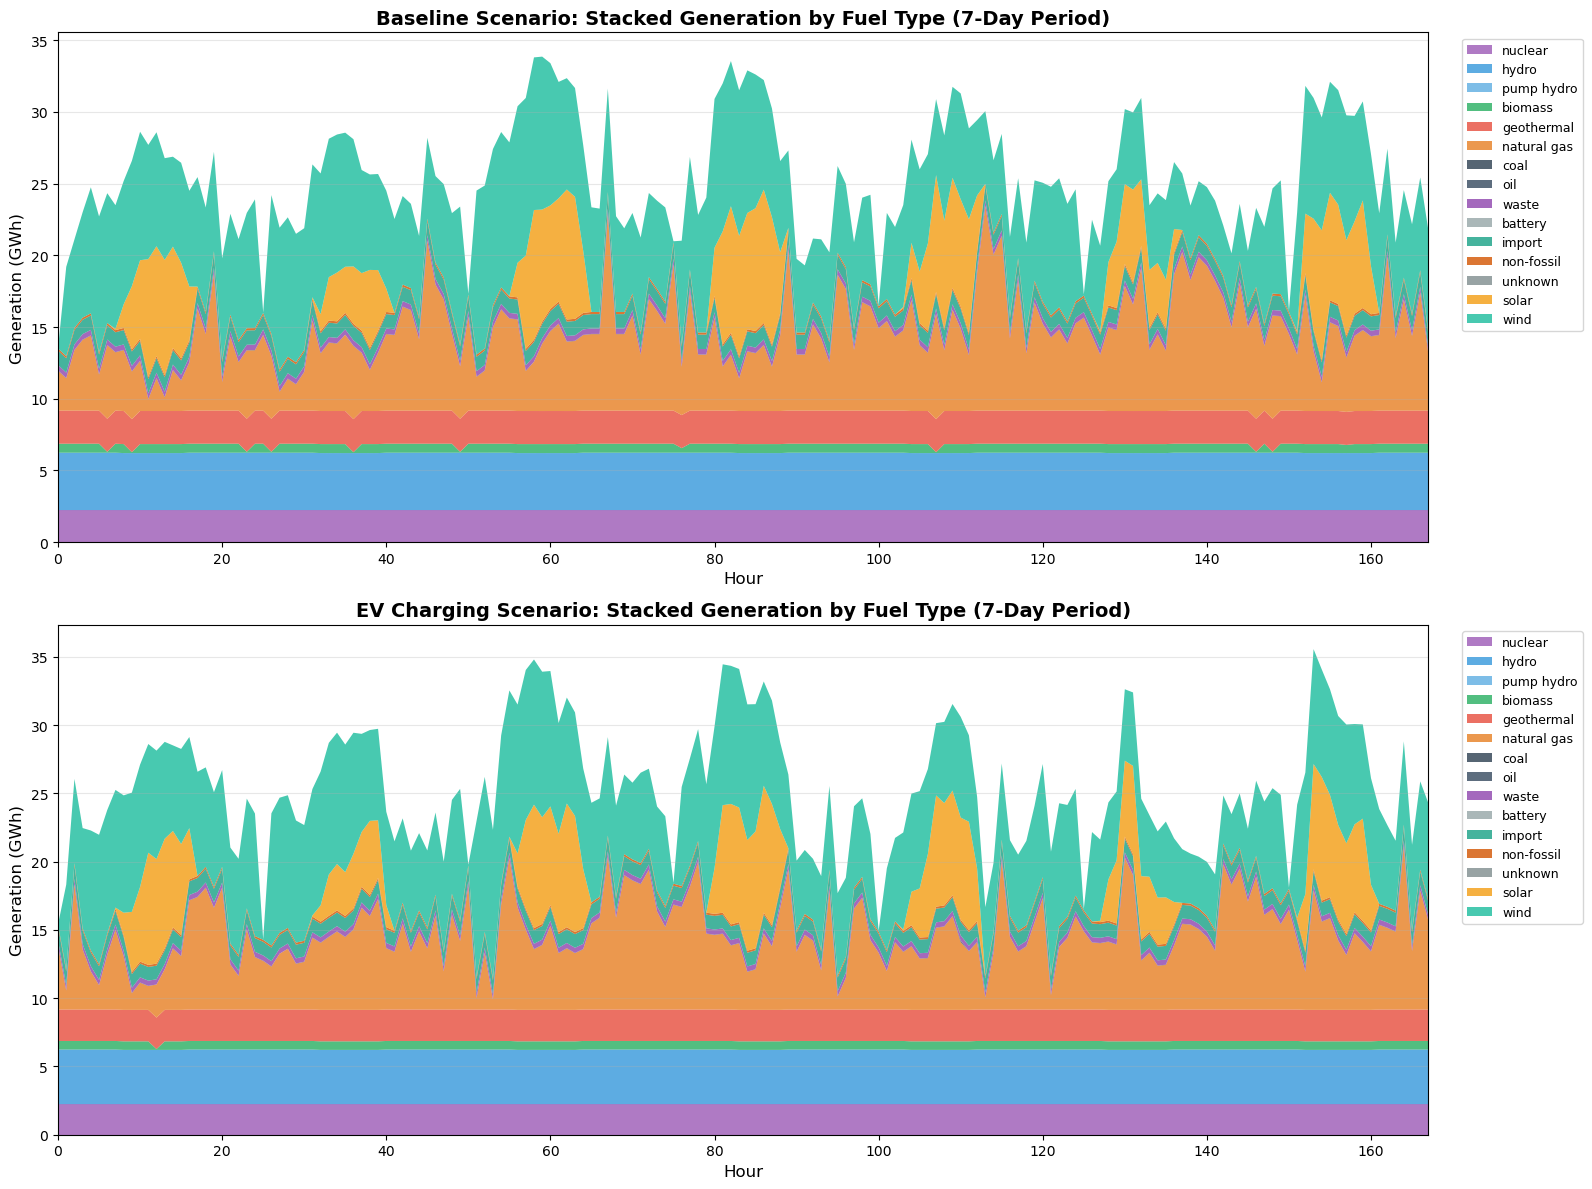

GENERATION SUMMARY BY SCENARIO

Baseline Scenario - Total Generation by Fuel:
  wind                :    1157.57 GWh
  natural gas         :     949.09 GWh
  hydro               :     670.47 GWh
  geothermal          :     387.23 GWh
  nuclear             :     376.32 GWh
  solar               :     363.95 GWh
  import              :     168.00 GWh
  biomass             :      99.84 GWh
  waste               :      63.87 GWh
  non-fossil          :      25.10 GWh
  coal                :       2.75 GWh

EV Charging Scenario - Total Generation by Fuel:
  wind                :    1157.57 GWh
  natural gas         :     944.16 GWh
  hydro               :     670.47 GWh
  geothermal          :     387.23 GWh
  nuclear             :     376.32 GWh
  solar               :     363.95 GWh
  import              :     168.00 GWh
  biomass             :     104.74 GWh
  waste               :      63.87 GWh
  non-fossil          :      25.10 GWh
  coal                :       2.69 GWh
  oil         

In [509]:
# Ensure output directory exists
if 'output_dir' not in locals():
    output_dir = 'ev_charging_results'
    os.makedirs(output_dir, exist_ok=True)

# Aggregate generation by hour and fuel for both scenarios
baseline_hourly = baseline_gen.groupby(['hour', 'fuel'])['generation_kwh'].sum().reset_index()
ev_hourly = ev_gen.groupby(['hour', 'fuel'])['generation_kwh'].sum().reset_index()

# Pivot to wide format for stacked area chart
baseline_pivot = baseline_hourly.pivot(index='hour', columns='fuel', values='generation_kwh').fillna(0)
ev_pivot = ev_hourly.pivot(index='hour', columns='fuel', values='generation_kwh').fillna(0)

# Define fuel colors (consistent across both charts)
fuel_colors = {
    'coal': '#2C3E50',
    'natural gas': '#E67E22',
    'oil': '#34495E',
    'nuclear': '#9B59B6',
    'hydro': '#3498DB',
    'pump hydro': '#5DADE2',
    'wind': '#1ABC9C',
    'solar': '#F39C12',
    'biomass': '#27AE60',
    'geothermal': '#E74C3C',
    'battery': '#95A5A6',
    'waste': '#8E44AD',
    'import': '#16A085',
    'non-fossil': '#D35400',
    'unknown': '#7F8C8D',
}

# Get all fuels present in either scenario
all_fuels = sorted(set(baseline_pivot.columns.tolist() + ev_pivot.columns.tolist()))

# Ensure both dataframes have the same columns
for fuel in all_fuels:
    if fuel not in baseline_pivot.columns:
        baseline_pivot[fuel] = 0
    if fuel not in ev_pivot.columns:
        ev_pivot[fuel] = 0

# Reorder columns: dispatchable at bottom (low to high cost), non-dispatchable at top (wind/solar at very top)
# Dispatchable fuels (ordered by typical marginal cost, low to high):
dispatchable_order = ['nuclear', 'hydro', 'pump hydro', 'biomass', 'geothermal', 
                      'natural gas', 'coal', 'oil', 'waste']
# Non-dispatchable fuels (wind and solar at top, then others):
non_dispatchable_order = ['battery', 'import', 'non-fossil', 'unknown', 'solar', 'wind']

# Combine: dispatchable first (will be at bottom of stack), then non-dispatchable (at top)
# Note: in stackplot, first items are at bottom, last items are at top
fuel_order = []
for fuel in dispatchable_order:
    if fuel in all_fuels:
        fuel_order.append(fuel)
for fuel in non_dispatchable_order:
    if fuel in all_fuels:
        fuel_order.append(fuel)
# Add any remaining fuels not in either list
for fuel in all_fuels:
    if fuel not in fuel_order:
        fuel_order.append(fuel)

baseline_pivot = baseline_pivot[fuel_order]
ev_pivot = ev_pivot[fuel_order]

# Convert to GWh for better readability
baseline_pivot_gwh = baseline_pivot / 1e6
ev_pivot_gwh = ev_pivot / 1e6

# Create the stacked area charts
fig, axes = plt.subplots(2, 1, figsize=(16, 12))

# Baseline scenario
ax1 = axes[0]
colors_list = [fuel_colors.get(fuel, '#CCCCCC') for fuel in fuel_order]
ax1.stackplot(baseline_pivot_gwh.index, 
              *[baseline_pivot_gwh[fuel] for fuel in fuel_order],
              labels=fuel_order,
              colors=colors_list,
              alpha=0.8)
ax1.set_xlabel('Hour', fontsize=12)
ax1.set_ylabel('Generation (GWh)', fontsize=12)
ax1.set_title('Baseline Scenario: Stacked Generation by Fuel Type (7-Day Period)', 
              fontsize=14, fontweight='bold')
ax1.legend(loc='upper left', bbox_to_anchor=(1.02, 1), fontsize=9, ncol=1)
ax1.grid(True, alpha=0.3, axis='y')
ax1.set_xlim(0, len(baseline_pivot_gwh) - 1)

# EV scenario
ax2 = axes[1]
ax2.stackplot(ev_pivot_gwh.index,
              *[ev_pivot_gwh[fuel] for fuel in fuel_order],
              labels=fuel_order,
              colors=colors_list,
              alpha=0.8)
ax2.set_xlabel('Hour', fontsize=12)
ax2.set_ylabel('Generation (GWh)', fontsize=12)
ax2.set_title('EV Charging Scenario: Stacked Generation by Fuel Type (7-Day Period)', 
              fontsize=14, fontweight='bold')
ax2.legend(loc='upper left', bbox_to_anchor=(1.02, 1), fontsize=9, ncol=1)
ax2.grid(True, alpha=0.3, axis='y')
ax2.set_xlim(0, len(ev_pivot_gwh) - 1)

plt.tight_layout()
plt.savefig(f'{output_dir}/stacked_generation_by_scenario.png', dpi=150, bbox_inches='tight')
plt.show()

# Print summary statistics
print("=" * 60)
print("GENERATION SUMMARY BY SCENARIO")
print("=" * 60)
print("\nBaseline Scenario - Total Generation by Fuel:")
baseline_totals = baseline_pivot_gwh.sum().sort_values(ascending=False)
for fuel, total in baseline_totals.items():
    if abs(total) > 0.01:  # Only show significant values
        print(f"  {fuel:20s}: {total:10.2f} GWh")

print("\nEV Charging Scenario - Total Generation by Fuel:")
ev_totals = ev_pivot_gwh.sum().sort_values(ascending=False)
for fuel, total in ev_totals.items():
    if abs(total) > 0.01:  # Only show significant values
        print(f"  {fuel:20s}: {total:10.2f} GWh")

print("\n" + "=" * 60)
print(f"Baseline Total: {baseline_pivot_gwh.sum().sum():.2f} GWh")
print(f"EV Scenario Total: {ev_pivot_gwh.sum().sum():.2f} GWh")
print(f"Difference: {(ev_pivot_gwh.sum().sum() - baseline_pivot_gwh.sum().sum()):.2f} GWh")
print("=" * 60)

In [510]:
# DIAGNOSTIC: Investigate why total generation is the same
print("=" * 60)
print("DIAGNOSTIC: Why is total generation the same?")
print("=" * 60)

# 1. Check total load from solutions
def get_total_load_from_solution(solution):
    """
    Calculate total load from solution.

    Note: 'net' values in solution are POWER in Watts (W), not energy!
    sum(net) over 168 time steps = sum of power values in Watts
    For 1-hour time steps: Energy (Wh) = Power (W) * 1 hour = Power (W)
    To convert Wh to GWh: divide by 1e9
    """
    total_load_watts = 0
    for source, node in solution._node.items():
        for handle, asset in node['assets'].items():
            if 'base_load' in handle.lower() or asset.get('_class') == 'Load':
                net = asset.get('net', [])
                if net:
                    # Load net is negative (consumption), so sum will be negative
                    total_load_watts += sum(net)
    return abs(total_load_watts)  # Return absolute value (sum of power in Watts)

baseline_total_load_watts = get_total_load_from_solution(baseline_solution)
ev_total_load_watts = get_total_load_from_solution(ev_solution)

# Convert to GWh: sum(Watts) * 1 hour = sum(Wh), then / 1e9 = GWh
baseline_total_load_gwh = baseline_total_load_watts / 1e9
ev_total_load_gwh = ev_total_load_watts / 1e9

print(f"\n1. Total Load Comparison:")
print(f"   Baseline: {baseline_total_load_gwh:.2f} GWh")
print(f"   EV Scenario: {ev_total_load_gwh:.2f} GWh")
print(f"   Difference: {ev_total_load_gwh - baseline_total_load_gwh:.2f} GWh")
print(f"   Expected EV Load: 106.42 GWh")

# 2. Check wastage
def get_wastage_from_solution(solution):
    """
    Get total wastage from solution.

    IMPORTANT: Wastage IS in Watt-seconds (W-s) from the energy balance constraint!
    Each wastage[i] represents energy (W-s) for that time step.
    To convert W-s to GWh: divide by 3.6e12
    """
    total_wastage_ws = 0
    for source, node in solution._node.items():
        wastage = node.get('wastage', [])
        if wastage:
            total_wastage_ws += sum(wastage)
    return total_wastage_ws

baseline_wastage_ws = get_wastage_from_solution(baseline_solution)
ev_wastage_ws = get_wastage_from_solution(ev_solution)

baseline_wastage_gwh = baseline_wastage_ws / 3.6e12  # W-s to GWh
ev_wastage_gwh = ev_wastage_ws / 3.6e12

print(f"\n2. Wastage Comparison:")
print(f"   Baseline: {baseline_wastage_gwh:.2f} GWh")
print(f"   EV Scenario: {ev_wastage_gwh:.2f} GWh")
print(f"   Wastage Reduction: {baseline_wastage_gwh - ev_wastage_gwh:.2f} GWh")

# 3. Check storage (battery/pump hydro) - look for net discharge
def get_storage_net_from_solution(solution):
    """
    Get net storage contribution (positive = discharge, negative = charge)

    NOTE: In nearly all GridGraph extraction code, 'net' for storage assets is
    tracked in watt-hours (Wh) not W-s, so conversion to GWh is:
        GWh = Wh / 1e9
    If in doubt, check a sample value.
    """
    total_net_wh = 0
    for source, node in solution._node.items():
        for handle, asset in node['assets'].items():
            fuel = asset.get('fuel', '').lower()
            if 'battery' in fuel or 'pump hydro' in fuel or asset.get('_class') == 'Store':
                net = asset.get('net', [])
                if net:
                    total_net_wh += sum(net)
    return total_net_wh

baseline_storage_net_wh = get_storage_net_from_solution(baseline_solution)
ev_storage_net_wh = get_storage_net_from_solution(ev_solution)

baseline_storage_gwh = baseline_storage_net_wh / 1e9  # Wh to GWh
ev_storage_gwh = ev_storage_net_wh / 1e9

print(f"\n3. Storage Net Contribution:")
print(f"   Baseline: {baseline_storage_gwh:.2f} GWh (positive = net discharge)")
print(f"   EV Scenario: {ev_storage_gwh:.2f} GWh")
print(f"   Additional Discharge: {ev_storage_gwh - baseline_storage_gwh:.2f} GWh")

# 4. Check total generation from extracted data (after unit fix)
# Note: generation_kwh already in kWh, so divide by 1e6 to get GWh
baseline_total_gen_gwh = baseline_gen['generation_kwh'].sum() / 1e6  # kWh to GWh
ev_total_gen_gwh = ev_gen['generation_kwh'].sum() / 1e6

print(f"\n4. Total Generation (from extraction):")
print(f"   Baseline: {baseline_total_gen_gwh:.2f} GWh")
print(f"   EV Scenario: {ev_total_gen_gwh:.2f} GWh")
print(f"   Difference: {ev_total_gen_gwh - baseline_total_gen_gwh:.2f} GWh")

# 5. Break down Load into Consumption vs Renewables

def breakdown_load_components(solution):
    """
    Break down Load assets into consumption vs renewables.
    
    We identify Load assets by checking if 'production' key exists:
    - If asset has 'production' key -> Producer (skip, already counted in generation)
    - Otherwise -> Load-type asset
    
    Then classify as:
    - Consumption: base_load assets (handle contains 'base_load')
    - Renewables: Load assets with fuel='solar' or fuel='wind'
    """
    consumption_watts = 0
    renewable_watts = 0
    
    for source, node in solution._node.items():
        for handle, asset in node['assets'].items():
            # Skip Producer assets (they have 'production' key)
            if 'production' in asset:
                continue
            
            # All non-Producer assets with 'net' are Load-type
            net = asset.get('net', [])
            if net:
                total_net = sum(net)
                
                # Check fuel type and handle name to classify
                fuel = str(asset.get('fuel', '')).lower()
                handle_lower = handle.lower()
                
                # Renewables are Load assets with solar/wind fuel
                is_renewable = (
                    'solar' in fuel or 'wind' in fuel or
                    'solar' in handle_lower or 'wind' in handle_lower
                )
                
                # Consumption loads are base_load assets
                is_consumption = 'base_load' in handle_lower
                
                if is_renewable:
                    # Renewable generation (net is negative, represents generation)
                    renewable_watts += abs(total_net)
                elif is_consumption:
                    # Consumption load (net is negative for consumption)
                    consumption_watts += abs(total_net)
    
    return consumption_watts, renewable_watts

# Debug: Print sample Load-type assets to verify classification
print("\nDEBUG: Sample Load-type assets (non-Producer) from baseline:")
sample_consumption = 0
sample_renewable = 0
for source, node in baseline_solution._node.items():
    for handle, asset in node['assets'].items():
        # Skip Producers
        if 'production' in asset:
            continue
        
        net = asset.get('net', [])
        if net and (sample_consumption < 6 or sample_renewable < 6):
            capacity = asset.get('installed_capacity', 0)
            fuel = asset.get('fuel', 'N/A')
            total_net = sum(net)
            fuel_lower = str(fuel).lower()
            handle_lower = handle.lower()
            is_renewable = ('solar' in fuel_lower or 'wind' in fuel_lower or 'solar' in handle_lower or 'wind' in handle_lower)
            is_consumption = 'base_load' in handle_lower
            classification = 'Renewable' if is_renewable else ('Consumption' if is_consumption else 'Unclassified')
            
            if is_consumption and sample_consumption < 6:
                print(f"  {handle}: fuel={fuel}, capacity={capacity/1e9:.2f} GW, net={total_net/1e9:.2f} GW -> {classification}")
                sample_consumption += 1
            elif is_renewable and sample_renewable < 6:
                print(f"  {handle}: fuel={fuel}, capacity={capacity/1e9:.2f} GW, net={total_net/1e9:.2f} GW -> {classification}")
                sample_renewable += 1

baseline_consumption_w, baseline_renewable_w = breakdown_load_components(baseline_solution)
ev_consumption_w, ev_renewable_w = breakdown_load_components(ev_solution)

baseline_consumption_gwh = baseline_consumption_w / 1e9
baseline_renewable_gwh = baseline_renewable_w / 1e9
ev_consumption_gwh = ev_consumption_w / 1e9
ev_renewable_gwh = ev_renewable_w / 1e9

print(f"\n5. Load Breakdown (Consumption vs Renewables):")
print(f"   Baseline:")
print(f"     Total 'Load': {baseline_total_load_gwh:.2f} GWh")
print(f"     - Consumption: {baseline_consumption_gwh:.2f} GWh")
print(f"     - Renewables: {baseline_renewable_gwh:.2f} GWh")
print(f"   EV Scenario:")
print(f"     Total 'Load': {ev_total_load_gwh:.2f} GWh")
print(f"     - Consumption: {ev_consumption_gwh:.2f} GWh")
print(f"     - Renewables: {ev_renewable_gwh:.2f} GWh")

# 6. Check imports/exports
def get_imports_exports_from_solution(solution):
    """
    Extract total imports and exports from solution.
    NetworkX graphs store edges in _adj (adjacency list).
    Transmission lines store 'transmission' (power flow from source to target in Watts).
    
    For each edge (source -> target):
    - 'transmission' is power sent from source (export from source)
    - 'transmission' * efficiency is power received at target (import to target)
    
    We sum all exports (from all sources) and all imports (to all targets).
    """
    total_imports_w = 0
    total_exports_w = 0
    
    # NetworkX graphs use _adj for edges (adjacency list)
    if hasattr(solution, '_adj'):
        for source in solution._adj:
            for target, edge_data in solution._adj[source].items():
                if 'lines' in edge_data:
                    for line_name, line_data in edge_data['lines'].items():
                        # Transmission line stores 'transmission' (power flow from source to target)
                        transmission = line_data.get('transmission', [])
                        efficiency = line_data.get('efficiency', 1.0)
                        
                        if transmission:
                            transmission_sum = sum(transmission)
                            
                            # Export: power sent from source
                            total_exports_w += transmission_sum
                            
                            # Import: power received at target (accounting for efficiency)
                            total_imports_w += transmission_sum * efficiency
    
    return total_imports_w, total_exports_w

# Debug: Check edge structure
print("\nDEBUG: Checking edge structure for imports/exports:")
if hasattr(baseline_solution, '_adj'):
    edge_count = sum(len(edges) for edges in baseline_solution._adj.values())
    print(f"  Found {edge_count} edges in solution._adj")
    if edge_count > 0:
        # Show first edge
        for source in baseline_solution._adj:
            for target, edge_data in baseline_solution._adj[source].items():
                print(f"  Edge: {source} -> {target}")
                print(f"    Keys: {list(edge_data.keys())}")
                if 'lines' in edge_data:
                    print(f"    Lines: {list(edge_data['lines'].keys())}")
                    for line_name, line_data in list(edge_data['lines'].items())[:1]:
                        print(f"      Line {line_name} keys: {list(line_data.keys())}")
                break
            if edge_count > 0:
                break
else:
    print("  No _adj attribute found")

baseline_imports_w, baseline_exports_w = get_imports_exports_from_solution(baseline_solution)
ev_imports_w, ev_exports_w = get_imports_exports_from_solution(ev_solution)

baseline_imports_gwh = baseline_imports_w / 1e9
baseline_exports_gwh = baseline_exports_w / 1e9
ev_imports_gwh = ev_imports_w / 1e9
ev_exports_gwh = ev_exports_w / 1e9

print(f"\n6. Imports/Exports:")
print(f"   Baseline:")
print(f"     Imports: {baseline_imports_gwh:.2f} GWh")
print(f"     Exports: {baseline_exports_gwh:.2f} GWh")
print(f"     Net Imports: {baseline_imports_gwh - baseline_exports_gwh:.2f} GWh")
print(f"   EV Scenario:")
print(f"     Imports: {ev_imports_gwh:.2f} GWh")
print(f"     Exports: {ev_exports_gwh:.2f} GWh")
print(f"     Net Imports: {ev_imports_gwh - ev_exports_gwh:.2f} GWh")

# 7. Complete Energy Balance
print(f"\n7. Complete Energy Balance:")
print(f"   Formula: Generation + Renewables + Imports = Consumption + Wastage + Exports")

print(f"\n   Baseline:")
baseline_supply = baseline_total_gen_gwh + baseline_renewable_gwh + baseline_imports_gwh
baseline_demand = baseline_consumption_gwh + baseline_wastage_gwh + baseline_exports_gwh
print(f"     Supply: {baseline_total_gen_gwh:.2f} + {baseline_renewable_gwh:.2f} + {baseline_imports_gwh:.2f} = {baseline_supply:.2f} GWh")
print(f"     Demand: {baseline_consumption_gwh:.2f} + {baseline_wastage_gwh:.2f} + {baseline_exports_gwh:.2f} = {baseline_demand:.2f} GWh")
print(f"     Balance: {baseline_supply:.2f} - {baseline_demand:.2f} = {baseline_supply - baseline_demand:.2f} GWh")

print(f"\n   EV Scenario:")
ev_supply = ev_total_gen_gwh + ev_renewable_gwh + ev_imports_gwh
ev_demand = ev_consumption_gwh + ev_wastage_gwh + ev_exports_gwh
print(f"     Supply: {ev_total_gen_gwh:.2f} + {ev_renewable_gwh:.2f} + {ev_imports_gwh:.2f} = {ev_supply:.2f} GWh")
print(f"     Demand: {ev_consumption_gwh:.2f} + {ev_wastage_gwh:.2f} + {ev_exports_gwh:.2f} = {ev_demand:.2f} GWh")
print(f"     Balance: {ev_supply:.2f} - {ev_demand:.2f} = {ev_supply - ev_demand:.2f} GWh")

print("\n" + "=" * 60)
print("CONCLUSION:")
print("=" * 60)

# Check EV load addition
# Check EV load addition - use total load difference (most reliable)
total_load_increase = ev_total_load_gwh - baseline_total_load_gwh
consumption_increase = ev_consumption_gwh - baseline_consumption_gwh

if abs(total_load_increase - 106.42) < 1:
    print(f"✓ EV load correctly added: {total_load_increase:.2f} GWh increase in total load")
    if abs(consumption_increase - 106.42) < 1:
        print(f"  ✓ Consumption breakdown confirms: {consumption_increase:.2f} GWh increase")
    else:
        print(f"  ⚠ Consumption breakdown shows: {consumption_increase:.2f} GWh (check if base_load assets are detected)")
else:
    print(f"⚠ EV load increase: {total_load_increase:.2f} GWh (expected 106.42 GWh)")

# Check energy balance
if abs(baseline_supply - baseline_demand) < 10:
    print(f"✓ Baseline energy balance checks out (difference: {baseline_supply - baseline_demand:.2f} GWh)")
else:
    print(f"⚠ Baseline energy balance issue: {baseline_supply - baseline_demand:.2f} GWh imbalance")
if abs(ev_supply - ev_demand) < 10:
    print(f"✓ EV scenario energy balance checks out (difference: {ev_supply - ev_demand:.2f} GWh)")
else:
    print(f"⚠ EV scenario energy balance issue: {ev_supply - ev_demand:.2f} GWh imbalance")

# Check generation response
gen_increase = ev_total_gen_gwh - baseline_total_gen_gwh
import_increase = (ev_imports_gwh - ev_exports_gwh) - (baseline_imports_gwh - baseline_exports_gwh)
renewable_change = ev_renewable_gwh - baseline_renewable_gwh

# total_load_increase already defined above

print(f"\nHow the system met the additional {total_load_increase:.2f} GWh EV load:")
print(f"  • Dispatchable generation increase: {gen_increase:.2f} GWh")
print(f"  • Net imports increase: {import_increase:.2f} GWh")
print(f"  • Renewable generation change: {renewable_change:.2f} GWh")
print(f"  • Wastage reduction: {baseline_wastage_gwh - ev_wastage_gwh:.2f} GWh")
total_response = gen_increase + import_increase + renewable_change + (baseline_wastage_gwh - ev_wastage_gwh)
print(f"  • Total response: {total_response:.2f} GWh")
print(f"  • Match to EV load: {abs(total_response - total_load_increase) < 1}")

print("=" * 60)

DIAGNOSTIC: Why is total generation the same?

1. Total Load Comparison:
   Baseline: 5308.02 GWh
   EV Scenario: 5414.44 GWh
   Difference: 106.42 GWh
   Expected EV Load: 106.42 GWh

2. Wastage Comparison:
   Baseline: 20.56 GWh
   EV Scenario: 20.08 GWh
   Wastage Reduction: 0.49 GWh

3. Storage Net Contribution:
   Baseline: 0.00 GWh (positive = net discharge)
   EV Scenario: 0.00 GWh
   Additional Discharge: 0.00 GWh

4. Total Generation (from extraction):
   Baseline: 4264.20 GWh
   EV Scenario: 4264.20 GWh
   Difference: 0.00 GWh

DEBUG: Sample Load-type assets (non-Producer) from baseline:
  installed_10818_combined: fuel=solar, capacity=0.00 GW, net=0.01 GW -> Renewable
  installed_11978_combined: fuel=solar, capacity=0.02 GW, net=0.20 GW -> Renewable
  installed_11979_combined: fuel=solar, capacity=0.00 GW, net=0.03 GW -> Renewable
  installed_11980_combined: fuel=solar, capacity=0.00 GW, net=0.03 GW -> Renewable
  installed_12090_combined: fuel=solar, capacity=0.00 GW, net=0

In [511]:
# Diagnostic: Check if emission factors are being read from the graph
print("=" * 60)
print("EMISSION FACTOR DIAGNOSTICS")
print("=" * 60)

# Sample a few assets to check their emission factors
sample_count = 0
for source, node in baseline_graph._node.items():
    if sample_count >= 5:
        break
    assets = node.get('assets', {})
    for handle, asset_data in list(assets.items())[:2]:  # Check first 2 assets per region
        if 'base_load' in handle or asset_data.get('type') == 'load':
            continue
        fuel = asset_data.get('fuel', 'unknown')
        co2 = asset_data.get('co2', 'NOT FOUND')
        nox = asset_data.get('nox', 'NOT FOUND')
        so2 = asset_data.get('so2', 'NOT FOUND')
        print(f"\nRegion: {source}, Asset: {handle}")
        print(f"  Fuel: {fuel}")
        print(f"  CO2 factor: {co2} kg/W-s")
        print(f"  NOx factor: {nox} kg/W-s")
        print(f"  SO2 factor: {so2} kg/W-s")
        sample_count += 1
        if sample_count >= 5:
            break

print("\n" + "=" * 60)
print("If you see 'NOT FOUND' or all zeros, emission factors need to be added to the JSON file.")
print("=" * 60)


EMISSION FACTOR DIAGNOSTICS

Region: WEC_BANC, Asset: installed_9621_combined
  Fuel: natural gas
  CO2 factor: 1.2195027871632844e-07 kg/W-s
  NOx factor: 6.662985747447537e-12 kg/W-s
  SO2 factor: 6.299888888888888e-13 kg/W-s

Region: WEC_BANC, Asset: installed_5747_combined
  Fuel: hydro
  CO2 factor: 0.0 kg/W-s
  NOx factor: 0.0 kg/W-s
  SO2 factor: 0.0 kg/W-s

Region: WEC_CALN, Asset: installed_14813_combined
  Fuel: solar
  CO2 factor: 0.0 kg/W-s
  NOx factor: 0.0 kg/W-s
  SO2 factor: 0.0 kg/W-s

Region: WEC_CALN, Asset: installed_12935_combined
  Fuel: waste
  CO2 factor: 1.5464598087064345e-11 kg/W-s
  NOx factor: 0.0 kg/W-s
  SO2 factor: 5.073479792732638e-11 kg/W-s

Region: WEC_LADW, Asset: installed_16469_combined
  Fuel: hydro
  CO2 factor: 0.0 kg/W-s
  NOx factor: 0.0 kg/W-s
  SO2 factor: 0.0 kg/W-s

If you see 'NOT FOUND' or all zeros, emission factors need to be added to the JSON file.


## Calculate Marginal Generation and Emissions


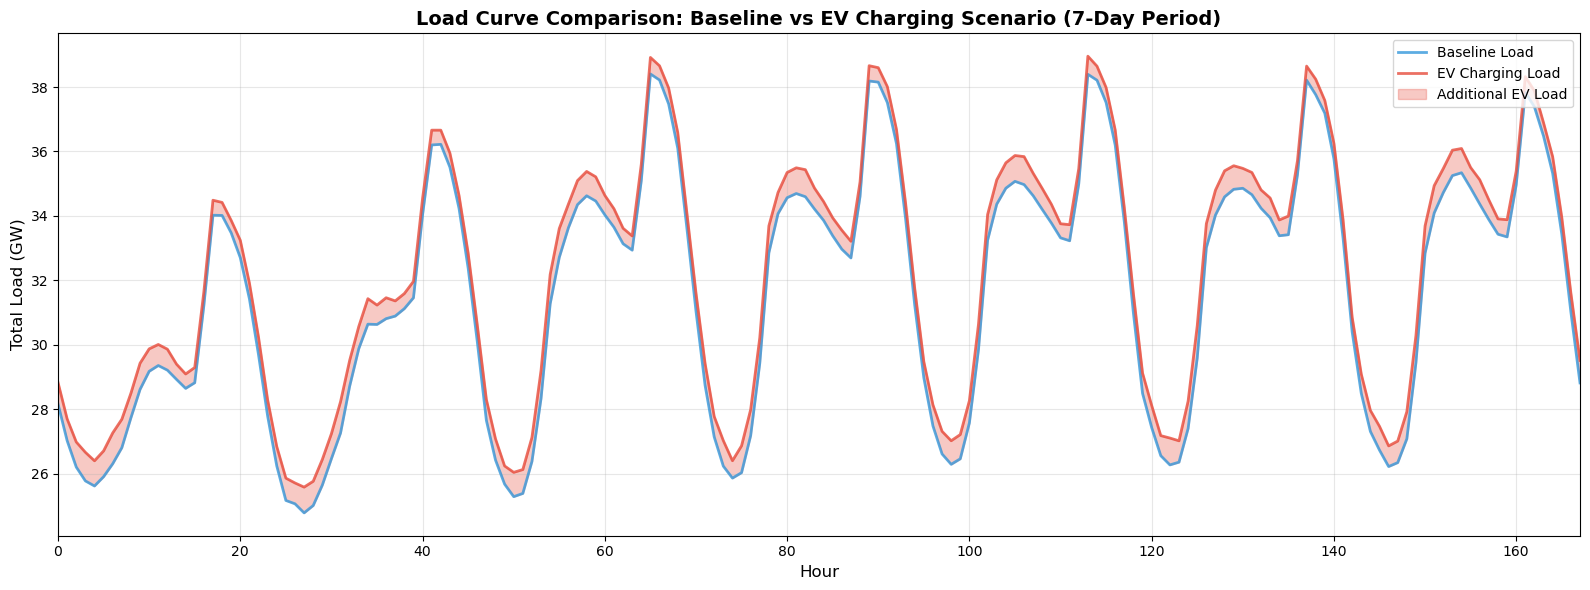

LOAD CURVE STATISTICS

Baseline Load:
  Average: 31.60 GW
  Peak: 38.41 GW
  Minimum: 24.78 GW
  Total Energy: 5308.02 GWh

EV Charging Load:
  Average: 32.23 GW
  Peak: 38.96 GW
  Minimum: 25.58 GW
  Total Energy: 5414.44 GWh

Additional Load (EV - Baseline):
  Average: 0.63 GW
  Peak: 1.00 GW
  Minimum: 0.39 GW
  Total Energy: 106.42 GWh
  Expected EV Energy: 106.42 GWh


In [512]:
# Extract load data from both scenarios
def extract_total_load_by_hour(solution):
    """
    Extract total load by hour from solution.
    
    Returns:
    -------
    hourly_load : np.array
        Array of total load (absolute value) in GW for each hour
    """
    # Initialize array for hourly loads
    num_hours = len(list(solution._node.values())[0]['assets'][list(list(solution._node.values())[0]['assets'].keys())[0]].get('net', []))
    hourly_load = np.zeros(num_hours)
    
    for source, node in solution._node.items():
        for handle, asset in node['assets'].items():
            if 'base_load' in handle.lower() or asset.get('_class') == 'Load':
                net = asset.get('net', [])
                if net and len(net) > 0:
                    # Load net is negative (consumption), convert to positive for display
                    hourly_load += np.abs(np.array(net))
    
    return hourly_load

# Extract hourly loads from both scenarios
baseline_load_hourly = extract_total_load_by_hour(baseline_solution)
ev_load_hourly = extract_total_load_by_hour(ev_solution)

# Convert to GW for better readability
baseline_load_gw = baseline_load_hourly / 1e9
ev_load_gw = ev_load_hourly / 1e9

# Create comparison plot
fig, ax = plt.subplots(figsize=(16, 6))

hours = np.arange(len(baseline_load_gw))

# Plot both load curves
ax.plot(hours, baseline_load_gw, label='Baseline Load', linewidth=2, color='#3498DB', alpha=0.8)
ax.plot(hours, ev_load_gw, label='EV Charging Load', linewidth=2, color='#E74C3C', alpha=0.8)

# Shade the difference
ax.fill_between(hours, baseline_load_gw, ev_load_gw, 
                 where=(ev_load_gw >= baseline_load_gw),
                 alpha=0.3, color='#E74C3C', label='Additional EV Load')

# Formatting
ax.set_xlabel('Hour', fontsize=12)
ax.set_ylabel('Total Load (GW)', fontsize=12)
ax.set_title('Load Curve Comparison: Baseline vs EV Charging Scenario (7-Day Period)', 
             fontsize=14, fontweight='bold')
ax.legend(loc='upper right', fontsize=10)
ax.grid(True, alpha=0.3)
ax.set_xlim(0, len(baseline_load_gw) - 1)

plt.tight_layout()
plt.savefig(f'{output_dir}/load_curve_comparison.png', dpi=150, bbox_inches='tight')
plt.show()

# Print statistics
print("=" * 60)
print("LOAD CURVE STATISTICS")
print("=" * 60)
print(f"\nBaseline Load:")
print(f"  Average: {baseline_load_gw.mean():.2f} GW")
print(f"  Peak: {baseline_load_gw.max():.2f} GW")
print(f"  Minimum: {baseline_load_gw.min():.2f} GW")
print(f"  Total Energy: {baseline_load_gw.sum():.2f} GWh")

print(f"\nEV Charging Load:")
print(f"  Average: {ev_load_gw.mean():.2f} GW")
print(f"  Peak: {ev_load_gw.max():.2f} GW")
print(f"  Minimum: {ev_load_gw.min():.2f} GW")
print(f"  Total Energy: {ev_load_gw.sum():.2f} GWh")

print(f"\nAdditional Load (EV - Baseline):")
additional_load = ev_load_gw - baseline_load_gw
print(f"  Average: {additional_load.mean():.2f} GW")
print(f"  Peak: {additional_load.max():.2f} GW")
print(f"  Minimum: {additional_load.min():.2f} GW")
print(f"  Total Energy: {additional_load.sum():.2f} GWh")
print(f"  Expected EV Energy: 106.42 GWh")
print("=" * 60)

In [513]:
# Merge baseline and EV scenarios to calculate differences
# Use hour, region, asset, fuel as keys
merge_cols = ['hour', 'region', 'asset', 'fuel']

# Merge on these columns
marginal_df = ev_gen.merge(
    baseline_gen,
    on=merge_cols,
    suffixes=('_ev', '_baseline'),
    how='outer'
).fillna(0)

# Calculate marginal generation (difference)
marginal_df['marginal_generation_kw'] = (
    marginal_df['generation_kw_ev'] - marginal_df['generation_kw_baseline']
)
marginal_df['marginal_generation_kwh'] = (
    marginal_df['generation_kwh_ev'] - marginal_df['generation_kwh_baseline']
)

# Use emission factors from EV scenario (should be same as baseline)
marginal_df['co2_factor'] = marginal_df['co2_factor_ev'].fillna(marginal_df['co2_factor_baseline'])
marginal_df['nox_factor'] = marginal_df['nox_factor_ev'].fillna(marginal_df['nox_factor_baseline'])
marginal_df['so2_factor'] = marginal_df['so2_factor_ev'].fillna(marginal_df['so2_factor_baseline'])

# Calculate emissions
# Emission factors are in kg per W-s, generation is in W
# For hourly emissions: generation_kw * 1000 (to W) * 3600 (seconds) * factor
# Or: generation_kwh * 1000 (to Wh) * 3600 (seconds/hour) * factor
# Actually, if factor is kg/W-s, then for 1 hour: W * 3600 s * factor = kg
# So: marginal_generation_kw * 1000 * 3600 * factor = kg
# Or: marginal_generation_kwh * 1000 * 3600 * factor = kg (but kWh already includes the hour)
# Let's use: marginal_generation_kw * 1000 * 3600 * factor

marginal_df['co2_emissions_kg'] = (
    marginal_df['marginal_generation_kw'] * 1000 * 3600 * marginal_df['co2_factor']
)
marginal_df['nox_emissions_kg'] = (
    marginal_df['marginal_generation_kw'] * 1000 * 3600 * marginal_df['nox_factor']
)
marginal_df['so2_emissions_kg'] = (
    marginal_df['marginal_generation_kw'] * 1000 * 3600 * marginal_df['so2_factor']
)

# Add day column (assuming hour 0 is start of period)
marginal_df['day'] = marginal_df['hour'] // 24

print(f"Marginal generation calculated for {len(marginal_df)} records")
print(f"\nTotal marginal generation by fuel:")
print(marginal_df.groupby('fuel')['marginal_generation_kwh'].sum().sort_values(ascending=False))


Marginal generation calculated for 182280 records

Total marginal generation by fuel:
fuel
biomass        4.900312e+06
oil            1.013000e+05
pump hydro     1.299900e-01
battery        6.235580e-02
hydro          0.000000e+00
import         0.000000e+00
geothermal     0.000000e+00
solar          0.000000e+00
waste          0.000000e+00
nuclear        0.000000e+00
non-fossil     0.000000e+00
wind           0.000000e+00
unknown       -2.581989e-17
coal          -6.800000e+04
natural gas   -4.933612e+06
Name: marginal_generation_kwh, dtype: float64


## Aggregate Results by Hour, Day, and Year


In [514]:
# Fix: Create period_results if it doesn't exist (for backward compatibility)
if 'period_results' in locals() and 'period_results' not in locals():
    period_results = period_results.copy()
    print("Created period_results from period_results")
elif 'period_results' not in locals():
    print("ERROR: Neither period_results nor period_results found. Please run the aggregation cell first.")


In [515]:
# Aggregate by hour
hourly_results = marginal_df.groupby(['hour', 'fuel']).agg({
    'marginal_generation_kwh': 'sum',
    'co2_emissions_kg': 'sum',
    'nox_emissions_kg': 'sum',
    'so2_emissions_kg': 'sum',
}).reset_index()

# Aggregate by day
daily_results = marginal_df.groupby(['day', 'fuel']).agg({
    'marginal_generation_kwh': 'sum',
    'co2_emissions_kg': 'sum',
    'nox_emissions_kg': 'sum',
    'so2_emissions_kg': 'sum',
}).reset_index()

# Aggregate by period (all data - 7 days)
period_results = marginal_df.groupby('fuel').agg({
    'marginal_generation_kwh': 'sum',
    'co2_emissions_kg': 'sum',
    'nox_emissions_kg': 'sum',
    'so2_emissions_kg': 'sum',
}).reset_index()

print("=" * 60)
print("7-DAY PERIOD SUMMARY BY FUEL TYPE")
print("=" * 60)
print(period_results.to_string(index=False))

print("\n" + "=" * 60)
print("TOTAL MARGINAL GENERATION AND EMISSIONS")
print("=" * 60)
print(f"Total Marginal Generation: {period_results['marginal_generation_kwh'].sum() / 1e6:.2f} GWh")
print(f"Total CO2 Emissions: {period_results['co2_emissions_kg'].sum() / 1e6:.2f} million kg CO2")
print(f"Total NOx Emissions: {period_results['nox_emissions_kg'].sum() / 1e6:.2f} million kg NOx")
print(f"Total SO2 Emissions: {period_results['so2_emissions_kg'].sum() / 1e6:.2f} million kg SO2")


7-DAY PERIOD SUMMARY BY FUEL TYPE
       fuel  marginal_generation_kwh  co2_emissions_kg  nox_emissions_kg  so2_emissions_kg
    battery             6.235580e-02      0.000000e+00          0.000000          0.000000
    biomass             4.900312e+06      2.736011e+04       3003.504366        644.544758
       coal            -6.800000e+04     -5.021346e+04       -123.592934       -267.265478
 geothermal             0.000000e+00      0.000000e+00          0.000000          0.000000
      hydro             0.000000e+00      0.000000e+00          0.000000          0.000000
     import             0.000000e+00      0.000000e+00          0.000000          0.000000
natural gas            -4.933612e+06      1.487308e+07      59930.089382        210.321313
 non-fossil             0.000000e+00      0.000000e+00          0.000000          0.000000
    nuclear             0.000000e+00      0.000000e+00          0.000000          0.000000
        oil             1.013000e+05      8.908129e+04  

## Export Results to CSV Files


In [516]:
# Export to CSV files
output_dir = 'ev_charging_results'
os.makedirs(output_dir, exist_ok=True)

# Hourly results
hourly_results.to_csv(f'{output_dir}/hourly_marginal_generation_emissions.csv', index=False)
print(f"Hourly results saved to {output_dir}/hourly_marginal_generation_emissions.csv")

# Daily results
daily_results.to_csv(f'{output_dir}/daily_marginal_generation_emissions.csv', index=False)
print(f"Daily results saved to {output_dir}/daily_marginal_generation_emissions.csv")

# Period results
period_results.to_csv(f'{output_dir}/period_marginal_generation_emissions.csv', index=False)
print(f"Period results saved to {output_dir}/period_marginal_generation_emissions.csv")

# Detailed hourly results (with region and asset info)
marginal_df.to_csv(f'{output_dir}/detailed_hourly_marginal_results.csv', index=False)
print(f"Detailed hourly results saved to {output_dir}/detailed_hourly_marginal_results.csv")


Hourly results saved to ev_charging_results/hourly_marginal_generation_emissions.csv
Daily results saved to ev_charging_results/daily_marginal_generation_emissions.csv
Period results saved to ev_charging_results/period_marginal_generation_emissions.csv
Detailed hourly results saved to ev_charging_results/detailed_hourly_marginal_results.csv


## Visualizations


In [517]:
# Diagnostic: Check period_results before plotting
print("=" * 60)
print("DIAGNOSTIC: Checking period_results for Plot 2")
print("=" * 60)
if 'period_results' not in locals():
    print("ERROR: period_results variable not found!")
    print("Please run the aggregation cell (cell 18) first.")
elif period_results is None or len(period_results) == 0:
    print("ERROR: period_results is empty or None!")
else:
    print(f"period_results shape: {period_results.shape}")
    print(f"Columns: {list(period_results.columns)}")
    print(f"\nTotal marginal generation: {period_results['marginal_generation_kwh'].sum() / 1e6:.2f} GWh")
    print(f"\nMarginal generation by fuel:")
    fuel_totals = period_results.groupby('fuel')['marginal_generation_kwh'].sum().sort_values(ascending=False)
    for fuel, total in fuel_totals.items():
        if abs(total) > 1e-3:  # Only show significant values
            print(f"  {fuel:20s}: {total/1e6:10.2f} GWh")
print("=" * 60)


DIAGNOSTIC: Checking period_results for Plot 2
period_results shape: (15, 5)
Columns: ['fuel', 'marginal_generation_kwh', 'co2_emissions_kg', 'nox_emissions_kg', 'so2_emissions_kg']

Total marginal generation: 0.00 GWh

Marginal generation by fuel:
  biomass             :       4.90 GWh
  oil                 :       0.10 GWh
  pump hydro          :       0.00 GWh
  battery             :       0.00 GWh
  coal                :      -0.07 GWh
  natural gas         :      -4.93 GWh


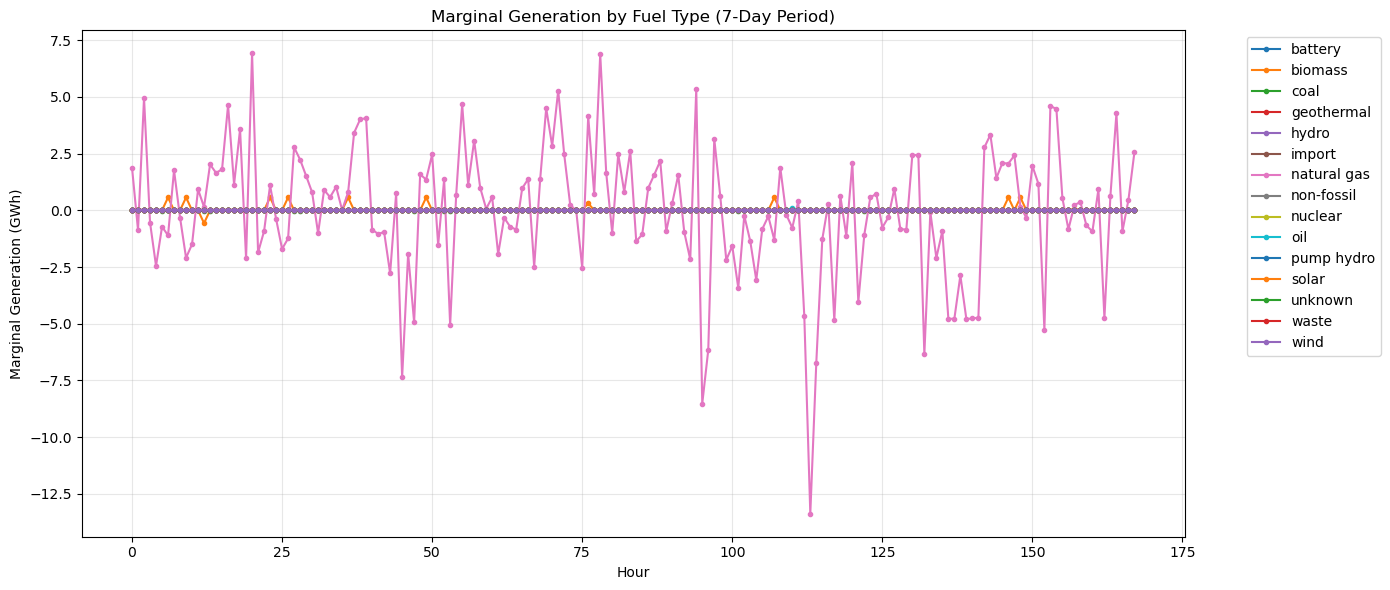

In [518]:
# Plot 1: Hourly marginal generation by fuel type (7 days)
fig, ax = plt.subplots(figsize=(14, 6))

for fuel in sorted(hourly_results['fuel'].unique()):
    fuel_data = hourly_results[hourly_results['fuel'] == fuel]
    if len(fuel_data) > 0:
        ax.plot(fuel_data['hour'], fuel_data['marginal_generation_kwh'] / 1e6, 
                label=fuel, marker='o', markersize=3)

ax.set_xlabel('Hour')
ax.set_ylabel('Marginal Generation (GWh)')
ax.set_title('Marginal Generation by Fuel Type (7-Day Period)')
ax.legend(bbox_to_anchor=(1.05, 1), loc='upper left')
ax.grid(True, alpha=0.3)
plt.tight_layout()
plt.savefig(f'{output_dir}/hourly_marginal_generation_7days.png', dpi=150)
plt.show()


In [519]:
## Aggregate Results by Hour, Day, and Period

# Aggregate by hour
hourly_results = marginal_df.groupby(['hour', 'fuel']).agg({
    'marginal_generation_kwh': 'sum',
    'co2_emissions_kg': 'sum',
    'nox_emissions_kg': 'sum',
    'so2_emissions_kg': 'sum',
}).reset_index()

# Aggregate by day
daily_results = marginal_df.groupby(['day', 'fuel']).agg({
    'marginal_generation_kwh': 'sum',
    'co2_emissions_kg': 'sum',
    'nox_emissions_kg': 'sum',
    'so2_emissions_kg': 'sum',
}).reset_index()

# Aggregate by period (all data - 7 days)
period_results = marginal_df.groupby('fuel').agg({
    'marginal_generation_kwh': 'sum',
    'co2_emissions_kg': 'sum',
    'nox_emissions_kg': 'sum',
    'so2_emissions_kg': 'sum',
}).reset_index()

print("=" * 60)
print("7-DAY PERIOD SUMMARY BY FUEL TYPE")
print("=" * 60)
print(period_results.to_string(index=False))

print("\n" + "=" * 60)
print("TOTAL MARGINAL GENERATION AND EMISSIONS (7 DAYS)")
print("=" * 60)
print(f"Total Marginal Generation: {period_results['marginal_generation_kwh'].sum() / 1e6:.2f} GWh")
print(f"Total CO2 Emissions: {period_results['co2_emissions_kg'].sum() / 1e6:.2f} million kg CO2")
print(f"Total NOx Emissions: {period_results['nox_emissions_kg'].sum() / 1e6:.2f} million kg NOx")
print(f"Total SO2 Emissions: {period_results['so2_emissions_kg'].sum() / 1e6:.2f} million kg SO2")

7-DAY PERIOD SUMMARY BY FUEL TYPE
       fuel  marginal_generation_kwh  co2_emissions_kg  nox_emissions_kg  so2_emissions_kg
    battery             6.235580e-02      0.000000e+00          0.000000          0.000000
    biomass             4.900312e+06      2.736011e+04       3003.504366        644.544758
       coal            -6.800000e+04     -5.021346e+04       -123.592934       -267.265478
 geothermal             0.000000e+00      0.000000e+00          0.000000          0.000000
      hydro             0.000000e+00      0.000000e+00          0.000000          0.000000
     import             0.000000e+00      0.000000e+00          0.000000          0.000000
natural gas            -4.933612e+06      1.487308e+07      59930.089382        210.321313
 non-fossil             0.000000e+00      0.000000e+00          0.000000          0.000000
    nuclear             0.000000e+00      0.000000e+00          0.000000          0.000000
        oil             1.013000e+05      8.908129e+04  

Plot: 4 fuels, Net: -0.00 GWh (+5.00, -5.00)


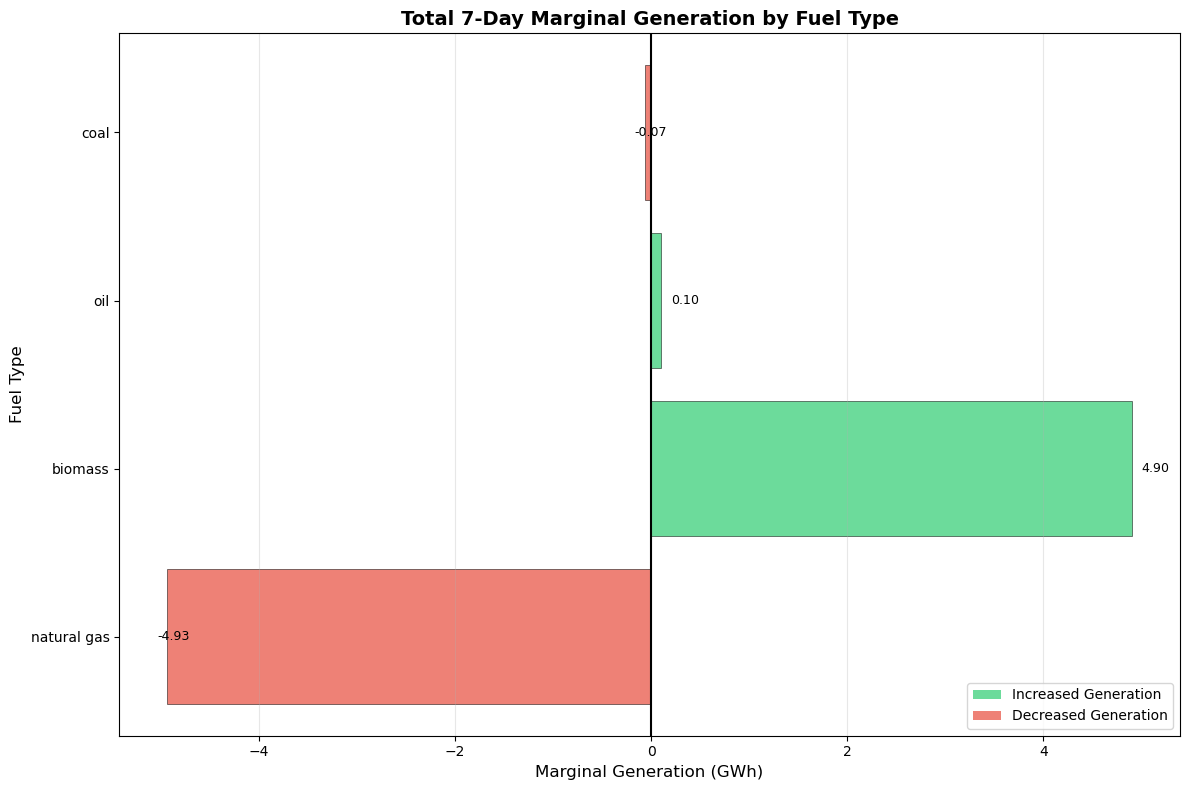

In [520]:
# Plot 2: Period marginal generation by fuel type (horizontal bar chart - more reliable)
fig, ax = plt.subplots(figsize=(12, 8))

# Check that period_results exists
if 'period_results' not in locals() or period_results is None or len(period_results) == 0:
    ax.text(0.5, 0.5, "No data available\n(Run aggregation cell first)", 
            ha='center', va='center', fontsize=16, transform=ax.transAxes)
    ax.set_title('Total 7-Day Marginal Generation by Fuel Type')
else:
    # Group by 'fuel' and sum 'marginal_generation_kwh'
    period_gen_by_fuel = period_results.groupby('fuel', as_index=False)['marginal_generation_kwh'].sum()
    
    # Convert to GWh
    period_gen_by_fuel['marginal_generation_gwh'] = period_gen_by_fuel['marginal_generation_kwh'] / 1e6
    
    # Filter to significant values (> 0.001 GWh absolute)
    period_gen_by_fuel = period_gen_by_fuel[period_gen_by_fuel['marginal_generation_gwh'].abs() > 0.001]
    
    if period_gen_by_fuel.empty:
        ax.text(0.5, 0.5, "No significant data\n(All values < 0.001 GWh)", 
                ha='center', va='center', fontsize=14, transform=ax.transAxes)
        ax.set_title('Total 7-Day Marginal Generation by Fuel Type')
    else:
        # Sort by absolute value
        period_gen_by_fuel = period_gen_by_fuel.sort_values('marginal_generation_gwh', key=abs, ascending=False)
        
        # Color code: green for positive, red for negative
        colors = ['#2ecc71' if x > 0 else '#e74c3c' for x in period_gen_by_fuel['marginal_generation_gwh']]
        
        # Create horizontal bar chart
        bars = ax.barh(period_gen_by_fuel['fuel'], period_gen_by_fuel['marginal_generation_gwh'], 
                       color=colors, alpha=0.7, edgecolor='black', linewidth=0.5)
        
        # Add value labels
        max_abs = period_gen_by_fuel['marginal_generation_gwh'].abs().max()
        for i, (fuel, value) in enumerate(zip(period_gen_by_fuel['fuel'], 
                                                period_gen_by_fuel['marginal_generation_gwh'])):
            label_x = value + (max_abs * 0.02 if value >= 0 else -max_abs * 0.02)
            ax.text(label_x, i, f'{value:.2f}', va='center', fontsize=9)
        
        ax.set_xlabel('Marginal Generation (GWh)', fontsize=12)
        ax.set_ylabel('Fuel Type', fontsize=12)
        ax.set_title('Total 7-Day Marginal Generation by Fuel Type', fontsize=14, fontweight='bold')
        ax.axvline(x=0, color='black', linestyle='-', linewidth=1.5)
        ax.grid(True, alpha=0.3, axis='x')
        
        # Legend
        from matplotlib.patches import Patch
        legend_elements = [
            Patch(facecolor='#2ecc71', alpha=0.7, label='Increased Generation'),
            Patch(facecolor='#e74c3c', alpha=0.7, label='Decreased Generation')
        ]
        ax.legend(handles=legend_elements, loc='lower right', fontsize=10)
        
        # Print summary
        pos = period_gen_by_fuel[period_gen_by_fuel['marginal_generation_gwh'] > 0]['marginal_generation_gwh'].sum()
        neg = period_gen_by_fuel[period_gen_by_fuel['marginal_generation_gwh'] < 0]['marginal_generation_gwh'].sum()
        print(f"Plot: {len(period_gen_by_fuel)} fuels, Net: {pos + neg:.2f} GWh (+{pos:.2f}, {neg:.2f})")

plt.tight_layout()
plt.savefig(f'{output_dir}/period_marginal_generation_by_fuel.png', dpi=150, bbox_inches='tight')
plt.show()

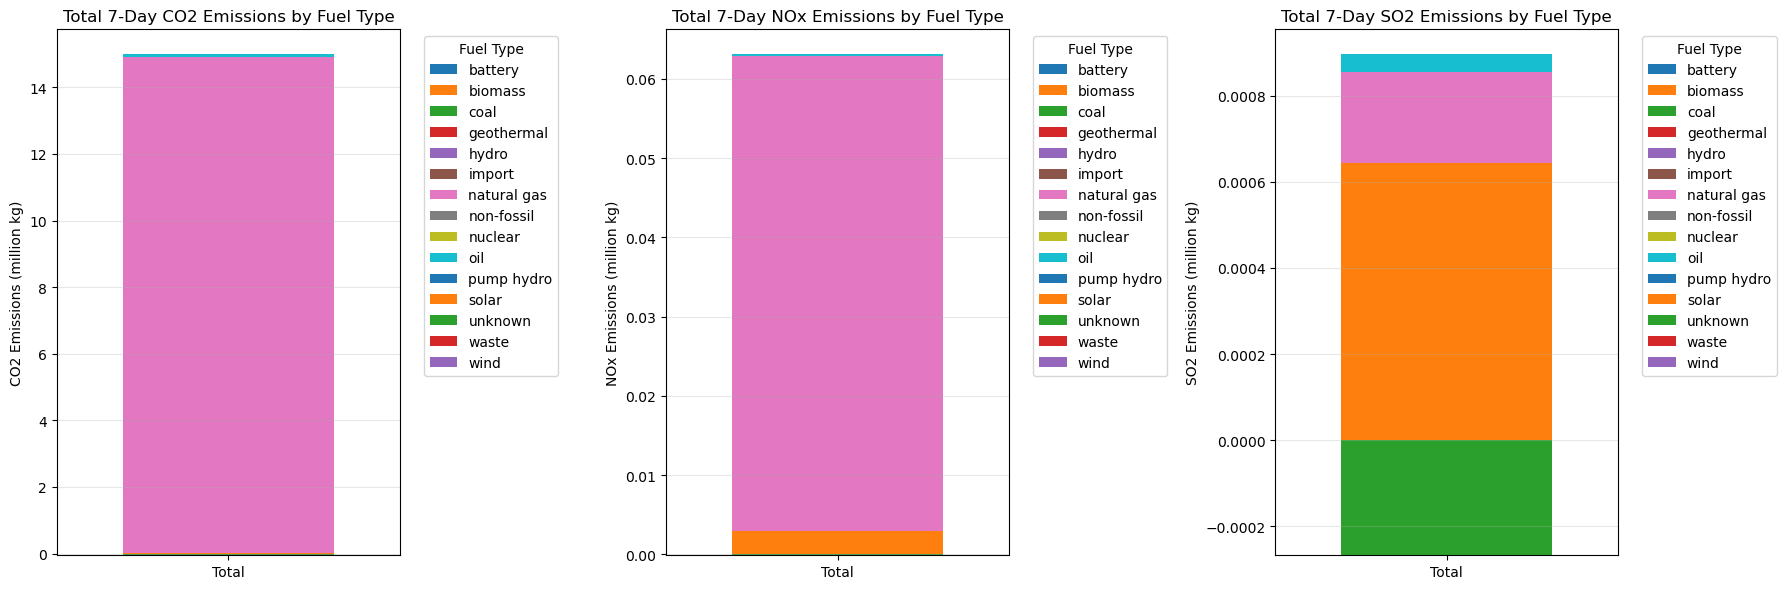

In [521]:
# Plot 3: Period emissions by fuel type
fig, axes = plt.subplots(1, 3, figsize=(18, 6))

emissions = ['co2_emissions_kg', 'nox_emissions_kg', 'so2_emissions_kg']
titles = ['CO2 Emissions', 'NOx Emissions', 'SO2 Emissions']
units = ['million kg', 'million kg', 'million kg']

for ax, emission, title, unit in zip(axes, emissions, titles, units):
    # Group by fuel, sum emissions, convert to DataFrame for plotting
    period_sum_by_fuel = period_results.groupby('fuel', as_index=False)[emission].sum()
    period_sum_by_fuel[emission] = period_sum_by_fuel[emission] / 1e6  # Convert to million kg

    # Pivot to match the expected plotting format: columns=fuel, index=row with emission sums
    plot_df = period_sum_by_fuel.set_index('fuel').T

    plot_df.plot(kind='bar', stacked=True, ax=ax, width=0.8)
    ax.set_ylabel(f'{title} ({unit})')
    ax.set_title(f'Total 7-Day {title} by Fuel Type')
    ax.set_xticklabels(['Total'], rotation=0)
    ax.legend(title='Fuel Type', bbox_to_anchor=(1.05, 1), loc='upper left')
    ax.grid(True, alpha=0.3, axis='y')

plt.tight_layout()
plt.savefig(f'{output_dir}/period_emissions_by_fuel.png', dpi=150)
plt.show()


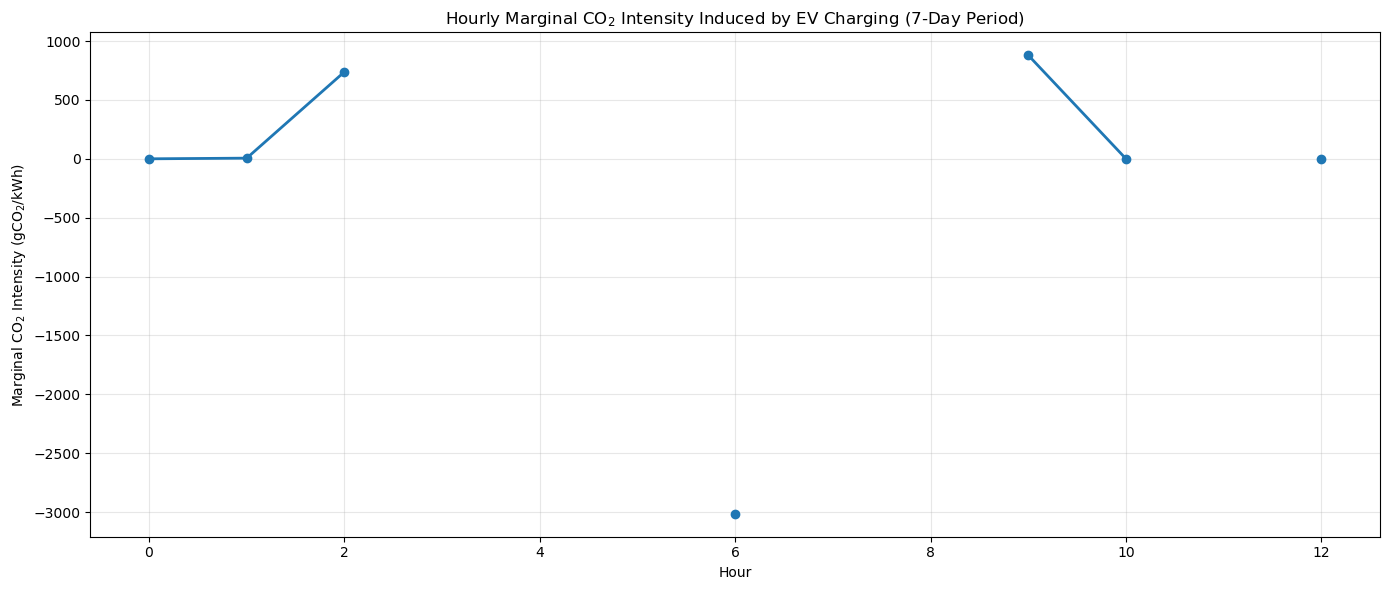

In [526]:
# Plot 4: Hourly marginal CO2 emissions intensity (gCO2/kWh) over the 7-day period (0-168 hours, no merging/grouping)
fig, ax = plt.subplots(figsize=(14, 6))

# Why is this plot non-continuous?
# Because whenever marginal_generation_kwh is zero for an hour, the CO2 intensity is undefined or "nan."
# This results in gaps in the line plot (matplotlib breaks the line when encountering np.nan).
# These discontinuities correctly reflect hours where there was zero additional generation attributed to EV charging,
# and thus no emissions intensity can be defined (cannot divide by zero energy).

import numpy as np

n_hours = len(period_results)
hours = np.arange(n_hours)

hourly_gen = period_results['marginal_generation_kwh'].values
hourly_co2 = period_results['co2_emissions_kg'].values

# Where marginal_generation_kwh == 0, set to np.nan to avoid division by zero and leave gaps in the plot
hourly_gen_nozero = np.where(hourly_gen == 0, np.nan, hourly_gen)
co2_intensity = (hourly_co2 * 1000) / hourly_gen_nozero  # gCO2/kWh

ax.plot(hours, co2_intensity, linewidth=2, marker='o')

ax.set_xlabel('Hour')
ax.set_ylabel('Marginal CO$_2$ Intensity (gCO$_2$/kWh)')
ax.set_title('Hourly Marginal CO$_2$ Intensity Induced by EV Charging (7-Day Period)')
ax.grid(True, alpha=0.3)
plt.tight_layout()
plt.savefig(f'{output_dir}/hourly_marginal_co2_intensity.png', dpi=150)
plt.show()


## Summary Statistics


In [523]:
print("=" * 60)
print("SUMMARY STATISTICS (7-DAY PERIOD)")
print("=" * 60)

# Overall statistics
total_ev_energy = ev_charging_load.sum() / 1e6  # MWh
total_ev_energy_gwh = total_ev_energy / 1e3     # GWh
total_marginal_gen = period_results['marginal_generation_kwh'].sum() / 1e6  # MWh
total_marginal_gen_gwh = total_marginal_gen / 1e3  # GWh
total_co2 = period_results['co2_emissions_kg'].sum() / 1e6  # metric tons

print(f"\nTotal EV Charging Energy Demand: {total_ev_energy_gwh:.2f} GWh")
print(f"Total Marginal Generation: {total_marginal_gen_gwh:.2f} GWh")
print(f"Total Marginal CO2 Emissions: {total_co2:.2f} metric tons ({total_co2 * 1000:.2f} thousand kg)")

# Average emissions intensity
if total_marginal_gen > 0:
    avg_co2_intensity = (total_co2 * 1e6) / (total_marginal_gen * 1e3)  # g CO2 per kWh
    avg_co2_intensity_kg = (total_co2 * 1e6) / (total_marginal_gen * 1e6)  # kg CO2 per kWh
    print(f"\nAverage Marginal CO2 Intensity: {avg_co2_intensity_kg:.4f} kg CO2 per kWh")

# By fuel type
print("\n" + "-" * 60)
print("MARGINAL GENERATION BY FUEL TYPE:")
print("-" * 60)
fuel_sums_gen = period_results.groupby('fuel')['marginal_generation_kwh'].sum()
total_fuel_gen = fuel_sums_gen.sum()
for fuel, val in fuel_sums_gen.items():
    val_gwh = val / 1e6
    percent = (val / total_fuel_gen * 100) if total_fuel_gen > 0 else 0
    print(f"  {fuel:20s}: {val_gwh:10.2f} GWh ({percent:.1f}%)")

print("\n" + "-" * 60)
print("MARGINAL CO2 EMISSIONS BY FUEL TYPE:")
print("-" * 60)
fuel_sums_co2 = period_results.groupby('fuel')['co2_emissions_kg'].sum()
total_fuel_co2 = fuel_sums_co2.sum()
for fuel, val in fuel_sums_co2.items():
    val_kt = val / 1e6      # metric tons
    percent = (val / total_fuel_co2 * 100) if total_fuel_co2 > 0 else 0
    print(f"  {fuel:20s}: {val_kt:10.2f} metric tons ({percent:.1f}%)")


SUMMARY STATISTICS (7-DAY PERIOD)

Total EV Charging Energy Demand: 106.42 GWh
Total Marginal Generation: 0.00 GWh
Total Marginal CO2 Emissions: 14.94 metric tons (14939.31 thousand kg)

Average Marginal CO2 Intensity: 752769433.8157 kg CO2 per kWh

------------------------------------------------------------
MARGINAL GENERATION BY FUEL TYPE:
------------------------------------------------------------
  battery             :       0.00 GWh (314.2%)
  biomass             :       4.90 GWh (24691934421.9%)
  coal                :      -0.07 GWh (-342641764.6%)
  geothermal          :       0.00 GWh (0.0%)
  hydro               :       0.00 GWh (0.0%)
  import              :       0.00 GWh (0.0%)
  natural gas         :      -4.93 GWh (-24859728978.8%)
  non-fossil          :       0.00 GWh (0.0%)
  nuclear             :       0.00 GWh (0.0%)
  oil                 :       0.10 GWh (510435452.3%)
  pump hydro          :       0.00 GWh (655.0%)
  solar               :       0.00 GWh (0.0%)
